VALENTINA ACEVEDO MESA - 

LUIS EDUARDO GRAJALES HERNANDEZ - 

JUAN JOSÉ GARCÉS ROJAS - 1007409305

# Consulta: índices del EEG adicionales a la densidad espectral de potencia para clasificación en BCI

En este proyecto se busca analizar señales EEG asociadas a condiciones de reposo, imaginación de movimiento de mano izquierda e imaginación de movimiento de mano derecha. En el dataset EEG Motor Movement/Imagery, los eventos `T0`, `T1` y `T2` permiten identificar las condiciones experimentales. Para los runs 3, 4, 7, 8, 11 y 12, `T0` corresponde a reposo, `T1` corresponde a movimiento o imaginación de movimiento de la mano izquierda y `T2` corresponde a movimiento o imaginación de movimiento de la mano derecha [1].

Aunque la densidad espectral de potencia permite estudiar cómo se distribuye la energía de la señal EEG en diferentes bandas de frecuencia, en sistemas BCI basados en imaginación motora no siempre es suficiente usar únicamente este tipo de característica. Las señales EEG son no estacionarias, variables entre sujetos y pueden tener información relevante en el dominio temporal, espacial, tiempo-frecuencia y no lineal. Por esta razón, en la literatura se han propuesto diferentes índices adicionales para mejorar la representación de la señal y apoyar la clasificación de estados en BCI [2].

A continuación, se presentan índices adicionales a la densidad espectral de potencia que pueden implementarse en Python y que pueden aportar información útil para clasificar estados de reposo, imaginación de movimiento de mano izquierda e imaginación de movimiento de mano derecha.

---

## 1. Patrones Espaciales Comunes (Common Spatial Patterns, CSP)

Los Patrones Espaciales Comunes, conocidos como CSP, son una técnica de extracción de características espaciales ampliamente utilizada en BCI con EEG, especialmente en tareas de imaginación motora. El objetivo de CSP es encontrar combinaciones espaciales de los canales EEG que maximicen la varianza de una clase y minimicen la varianza de otra. De esta manera, los canales originales se transforman en nuevos componentes que resaltan mejor las diferencias entre condiciones [3].

Este índice es útil en imaginación motora porque las tareas de mano derecha y mano izquierda generan cambios en zonas sensorimotoras del cerebro. Por ejemplo, los canales `C3`, `Cz` y `C4` suelen ser de interés porque están relacionados con la actividad motora. En trabajos clásicos de BCI se ha demostrado que los filtros espaciales en EEG multicanal permiten extraer información discriminativa entre ensayos de imaginación de movimiento de mano izquierda y derecha [3].

Además, la librería MNE-Python incluye ejemplos de decodificación de imaginación motora usando CSP, donde las señales EEG son filtradas, transformadas con CSP y luego usadas como entrada para un clasificador [4].

**Aplicación en el proyecto:**

En este proyecto, CSP puede aplicarse sobre las épocas de EEG filtradas entre 8 y 30 Hz, rango que incluye principalmente los ritmos mu y beta. Las características obtenidas pueden usarse para comparar reposo, imaginación de mano izquierda e imaginación de mano derecha, o directamente para entrenar clasificadores como SVM, XGBoost o redes neuronales.

---

## 2. Parámetros de Hjorth

Los parámetros de Hjorth son características temporales que describen propiedades de la forma y variabilidad de una señal EEG. Estos parámetros fueron propuestos para el análisis de señales EEG en el dominio del tiempo y se componen principalmente de actividad, movilidad y complejidad [5].

### Actividad

La actividad mide la varianza de la señal. Se relaciona con la amplitud o energía general de la señal en el tiempo [5].

$$
Actividad = var(x(t))
$$

### Movilidad

La movilidad mide qué tan rápido cambia la señal en el tiempo. Se calcula a partir de la relación entre la varianza de la derivada de la señal y la varianza de la señal original [5].

$$
Movilidad = \sqrt{\frac{var(\frac{dx(t)}{dt})}{var(x(t))}}
$$

### Complejidad

La complejidad mide qué tan variable o irregular es la forma de la señal. Se calcula comparando la movilidad de la derivada con la movilidad de la señal original [5].

$$
Complejidad = \frac{Movilidad(\frac{dx(t)}{dt})}{Movilidad(x(t))}
$$

Estos parámetros son útiles porque permiten describir la señal EEG directamente en el dominio temporal, sin depender únicamente del análisis frecuencial. Además, tienen bajo costo computacional y pueden calcularse fácilmente para cada canal y cada época. En estudios de procesamiento EEG para imaginación motora se ha señalado que el análisis de estas señales requiere considerar tanto características temporales como frecuenciales debido a su comportamiento no estacionario [6].

**Aplicación en el proyecto:**

Para cada segmento EEG se pueden calcular los parámetros de Hjorth en los canales `C3`, `Cz` y `C4`. Por ejemplo:

- Actividad en C3.
- Movilidad en C3.
- Complejidad en C3.
- Actividad en C4.
- Movilidad en C4.
- Complejidad en C4.

Estos valores pueden almacenarse en un dataframe junto con el sujeto, el run y la condición evaluada.

---

## 3. Entropía de la señal EEG

La entropía es una medida que permite cuantificar el grado de irregularidad, desorden o complejidad de una señal. En EEG, puede ayudar a identificar diferencias entre condiciones que no son evidentes únicamente mediante la densidad espectral de potencia.

En paradigmas BCI de imaginación motora se han usado diferentes tipos de entropía, como entropía de Shannon, entropía muestral, entropía aproximada, entropía difusa y entropía de permutación. Una revisión enfocada en entropía aplicada a MI-BCI reporta que estas medidas son usadas como características para describir la complejidad de la señal EEG y apoyar tareas de clasificación [7].

Una señal más regular o más predecible tiende a presentar menor entropía, mientras que una señal más irregular tiende a presentar mayor entropía. Esto puede ser útil para comparar si las condiciones de reposo, mano izquierda imaginada y mano derecha imaginada presentan diferencias en la complejidad de la actividad cerebral.

**Aplicación en el proyecto:**

En este proyecto se puede implementar, por ejemplo, la entropía de permutación o la entropía muestral para cada época y cada canal. Estas características pueden complementar la información obtenida mediante la densidad espectral de potencia y los parámetros temporales.

---

## 4. Características tiempo-frecuencia mediante Wavelet

La transformada wavelet permite analizar cómo cambia el contenido frecuencial de una señal a lo largo del tiempo. Esto es importante en EEG porque las señales cerebrales no son completamente estacionarias. A diferencia de la densidad espectral de potencia tradicional, que resume la información frecuencial de un segmento completo, la transformada wavelet permite observar variaciones temporales dentro de la señal [8].

En clasificación de imaginación motora se han usado características basadas en wavelet, como energía por subbanda, entropía wavelet y características obtenidas mediante wavelet packet. Estos métodos permiten representar la señal EEG en el dominio tiempo-frecuencia y pueden aportar información complementaria para la clasificación [8], [9].

**Aplicación en el proyecto:**

En este proyecto se puede aplicar una transformada wavelet discreta a cada época EEG y calcular características como:

- Energía wavelet en C3.
- Entropía wavelet en C3.
- Energía wavelet en C4.
- Entropía wavelet en C4.
- Energía relativa por subbanda.

Estas características pueden compararse entre reposo, imaginación de mano izquierda e imaginación de mano derecha.

---

## Índices seleccionados para implementar

Para este proyecto se propone implementar los siguientes índices adicionales a la densidad espectral de potencia:

| Índice | Tipo de característica | Utilidad en BCI |
|---|---|---|
| CSP | Espacial | Resalta diferencias entre condiciones usando varios canales EEG |
| Parámetros de Hjorth | Temporal | Describe amplitud, variabilidad y complejidad de la señal |
| Entropía | No lineal | Mide irregularidad o complejidad de la señal EEG |
| Wavelet | Tiempo-frecuencia | Captura cambios de frecuencia a lo largo del tiempo |

Aunque todos los índices anteriores pueden aportar información útil, los tres más recomendados para iniciar el análisis son CSP, parámetros de Hjorth y entropía. Estos índices son relativamente directos de implementar en Python, complementan el análisis basado en potencia espectral y pueden generar características útiles para los modelos de clasificación.

---

## Conclusión

Con base en la revisión realizada, se concluye que para mejorar la clasificación de estados en BCI no es suficiente analizar únicamente la densidad espectral de potencia. En tareas de imaginación motora, las diferencias entre condiciones pueden observarse también en la distribución espacial de la actividad EEG, en la forma temporal de la señal, en su complejidad no lineal y en su comportamiento tiempo-frecuencia [2], [3], [7].

Por esta razón, se seleccionan como índices adicionales los Patrones Espaciales Comunes, los parámetros de Hjorth, la entropía y las características wavelet. Estos índices pueden calcularse sobre las épocas correspondientes a reposo, imaginación de mano izquierda e imaginación de mano derecha, y posteriormente utilizarse como entradas para modelos de clasificación.

---

## Referencias

[1] PhysioNet. *EEG Motor Movement/Imagery Dataset*. Disponible en:  
https://archive.physionet.org/pn4/eegmmidb/

[2] Degirmenci, M. et al. *Statistically significant features improve binary and multiple Motor Imagery task predictions from EEGs*. Frontiers in Human Neuroscience. Disponible en:  
https://www.frontiersin.org/journals/human-neuroscience/articles/10.3389/fnhum.2023.1223307/full

[3] Ramoser, H., Müller-Gerking, J., & Pfurtscheller, G. (2000). *Optimal spatial filtering of single trial EEG during imagined hand movement*. IEEE Transactions on Rehabilitation Engineering. Disponible en:  
https://pubmed.ncbi.nlm.nih.gov/11204034/

[4] MNE-Python. *Motor imagery decoding from EEG data using the Common Spatial Pattern (CSP)*. Disponible en:  
https://mne.tools/stable/auto_examples/decoding/decoding_csp_eeg.html

[5] Hjorth, B. (1970). *EEG analysis based on time domain properties*. Electroencephalography and Clinical Neurophysiology.

[6] Oh, S. H., Lee, Y. R., & Kim, H. N. *A Novel EEG Feature Extraction Method using Hjorth Parameter*. Disponible en:  
https://cspl.pusan.ac.kr/sites/cspl/download/internation_c/ICAEE2014_02_OSH.pdf

[7] *The Application of Entropy in Motor Imagery Paradigms of Brain–Computer Interfaces*. Disponible en:  
https://pmc.ncbi.nlm.nih.gov/articles/PMC11853529/

[8] *Motor imagery classification method based on relative wavelet packet energy and cloud model*. Disponible en:  
https://pmc.ncbi.nlm.nih.gov/articles/PMC9936148/

[9] *Feature Extraction of Motor Imagery EEG via Discrete Wavelet Transform*. Disponible en:  
https://www.mdpi.com/2079-9292/12/10/2207

In [2]:
# ============================================================
# 1. INSTALACIÓN E IMPORTACIÓN DE LIBRERÍAS
# ============================================================

!pip -q install mne tqdm

import os
import zipfile
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import mne
from tqdm import tqdm

In [3]:
# ============================================================
# 2. RUTAS DEL PROYECTO
# ============================================================

ZIP_PATH = Path("eeg-motor-movementimagery-dataset-1.0.0.zip")
DATA_DIR = Path("data_eeg")
RESULTS_DIR = Path("resultados")

DATA_DIR.mkdir(exist_ok=True)
RESULTS_DIR.mkdir(exist_ok=True)

print("Ruta del ZIP:", ZIP_PATH.resolve())
print("Carpeta de datos:", DATA_DIR.resolve())
print("Carpeta de resultados:", RESULTS_DIR.resolve())

if not ZIP_PATH.exists():
    raise FileNotFoundError(
        "No se encontró el archivo ZIP. "
        "Verifica que 'eeg-motor-movementimagery-dataset-1.0.0.zip' esté en la misma carpeta del notebook."
    )
else:
    print("ZIP encontrado correctamente.")

Ruta del ZIP: C:\Users\ASUS\Downloads\eeg-motor-movementimagery-dataset-1.0.0.zip
Carpeta de datos: C:\Users\ASUS\Downloads\data_eeg
Carpeta de resultados: C:\Users\ASUS\Downloads\resultados
ZIP encontrado correctamente.


In [4]:
# ============================================================
# 3. EXTRAER EL ZIP SOLO SI AÚN NO HAY ARCHIVOS EDF
# ============================================================

edf_existentes = list(DATA_DIR.rglob("*.edf"))

if len(edf_existentes) == 0:
    print("Extrayendo archivos del ZIP...")

    with zipfile.ZipFile(ZIP_PATH, "r") as zip_ref:
        zip_ref.extractall(DATA_DIR)

    print("Extracción finalizada.")
else:
    print("Ya hay archivos EDF extraídos. No se vuelve a extraer.")

Ya hay archivos EDF extraídos. No se vuelve a extraer.


In [5]:
# ============================================================
# 4. BUSCAR TODOS LOS ARCHIVOS EDF
# ============================================================

edf_files = sorted(DATA_DIR.rglob("*.edf"))

print("Cantidad total de archivos EDF encontrados:", len(edf_files))

for archivo in edf_files[:10]:
    print(archivo)

Cantidad total de archivos EDF encontrados: 1526
data_eeg\files\S001\S001R01.edf
data_eeg\files\S001\S001R02.edf
data_eeg\files\S001\S001R03.edf
data_eeg\files\S001\S001R04.edf
data_eeg\files\S001\S001R05.edf
data_eeg\files\S001\S001R06.edf
data_eeg\files\S001\S001R07.edf
data_eeg\files\S001\S001R08.edf
data_eeg\files\S001\S001R09.edf
data_eeg\files\S001\S001R10.edf


In [6]:
# ============================================================
# 5. SELECCIÓN DE RUNS DE INTERÉS
# ============================================================

# Para imaginación motora mano izquierda y mano derecha:
runs_imaginacion = ["R04", "R08", "R12"]

# Para movimiento real mano izquierda y mano derecha, si también lo necesitan:
runs_movimiento_real = ["R03", "R07", "R11"]

# Por ahora empecemos con imaginación motora
runs_interes = runs_imaginacion

edf_interes = [
    archivo for archivo in edf_files
    if any(run in archivo.name for run in runs_interes)
]

print("Cantidad de archivos de interés:", len(edf_interes))

for archivo in edf_interes[:20]:
    print(archivo.name)

Cantidad de archivos de interés: 327
S001R04.edf
S001R08.edf
S001R12.edf
S002R04.edf
S002R08.edf
S002R12.edf
S003R04.edf
S003R08.edf
S003R12.edf
S004R04.edf
S004R08.edf
S004R12.edf
S005R04.edf
S005R08.edf
S005R12.edf
S006R04.edf
S006R08.edf
S006R12.edf
S007R04.edf
S007R08.edf


In [7]:
# ============================================================
# 6. SELECCIONAR UN ARCHIVO DE PRUEBA
# ============================================================

archivo_prueba = None

for archivo in edf_interes:
    if "S001R04" in archivo.name:
        archivo_prueba = archivo
        break

print("Archivo seleccionado:")
print(archivo_prueba)

if archivo_prueba is None:
    raise FileNotFoundError("No se encontró S001R04.edf dentro de los archivos extraídos.")

Archivo seleccionado:
data_eeg\files\S001\S001R04.edf


In [8]:
# ============================================================
# 7. FUNCIÓN PARA LIMPIAR NOMBRES DE CANALES
# ============================================================

def limpiar_nombres_canales(raw):
    """
    Limpia los nombres de canales del dataset.
    Ejemplo:
    'C3..' -> 'C3'
    'Cz..' -> 'Cz'
    'C4..' -> 'C4'
    """
    nuevos_nombres = {}

    for canal in raw.ch_names:
        canal_limpio = canal.replace(".", "").replace(" ", "")
        nuevos_nombres[canal] = canal_limpio

    raw.rename_channels(nuevos_nombres)
    return raw

In [9]:
# ============================================================
# 8. LEER EL ARCHIVO EDF
# ============================================================

raw = mne.io.read_raw_edf(
    archivo_prueba,
    preload=True,
    verbose=False
)

raw = limpiar_nombres_canales(raw)

print(raw)
print("Frecuencia de muestreo:", raw.info["sfreq"], "Hz")
print("Número de canales:", len(raw.ch_names))
print("Duración:", raw.times[-1], "segundos")

print("\nPrimeros canales:")
print(raw.ch_names[:20])

<RawEDF | S001R04.edf, 64 x 20000 (125.0 s), ~9.8 MiB, data loaded>
Frecuencia de muestreo: 160.0 Hz
Número de canales: 64
Duración: 124.99375 segundos

Primeros canales:
['Fc5', 'Fc3', 'Fc1', 'Fcz', 'Fc2', 'Fc4', 'Fc6', 'C5', 'C3', 'C1', 'Cz', 'C2', 'C4', 'C6', 'Cp5', 'Cp3', 'Cp1', 'Cpz', 'Cp2', 'Cp4']


In [10]:
# ============================================================
# 9. REVISAR ANOTACIONES DEL ARCHIVO
# ============================================================

print(raw.annotations)

for onset, duration, description in zip(
    raw.annotations.onset,
    raw.annotations.duration,
    raw.annotations.description
):
    print(f"Inicio: {onset:.2f} s | Duración: {duration:.2f} s | Evento: {description}")

<Annotations | 30 segments: T0 (15), T1 (8), T2 (7)>
Inicio: 0.00 s | Duración: 4.20 s | Evento: T0
Inicio: 4.20 s | Duración: 4.10 s | Evento: T2
Inicio: 8.30 s | Duración: 4.20 s | Evento: T0
Inicio: 12.50 s | Duración: 4.10 s | Evento: T1
Inicio: 16.60 s | Duración: 4.20 s | Evento: T0
Inicio: 20.80 s | Duración: 4.10 s | Evento: T1
Inicio: 24.90 s | Duración: 4.20 s | Evento: T0
Inicio: 29.10 s | Duración: 4.10 s | Evento: T2
Inicio: 33.20 s | Duración: 4.20 s | Evento: T0
Inicio: 37.40 s | Duración: 4.10 s | Evento: T2
Inicio: 41.50 s | Duración: 4.20 s | Evento: T0
Inicio: 45.70 s | Duración: 4.10 s | Evento: T1
Inicio: 49.80 s | Duración: 4.20 s | Evento: T0
Inicio: 54.00 s | Duración: 4.10 s | Evento: T2
Inicio: 58.10 s | Duración: 4.20 s | Evento: T0
Inicio: 62.30 s | Duración: 4.10 s | Evento: T1
Inicio: 66.40 s | Duración: 4.20 s | Evento: T0
Inicio: 70.60 s | Duración: 4.10 s | Evento: T2
Inicio: 74.70 s | Duración: 4.20 s | Evento: T0
Inicio: 78.90 s | Duración: 4.10 s | E

In [11]:
# ============================================================
# 10. SELECCIONAR CANALES DE INTERÉS
# ============================================================

canales_interes = ["C3", "Cz", "C4"]

canales_disponibles = [
    canal for canal in canales_interes
    if canal in raw.ch_names
]

print("Canales disponibles:", canales_disponibles)

raw_canales = raw.copy().pick(canales_disponibles)

print(raw_canales)
print(raw_canales.ch_names)

Canales disponibles: ['C3', 'Cz', 'C4']
<RawEDF | S001R04.edf, 3 x 20000 (125.0 s), ~476 KiB, data loaded>
['C3', 'Cz', 'C4']


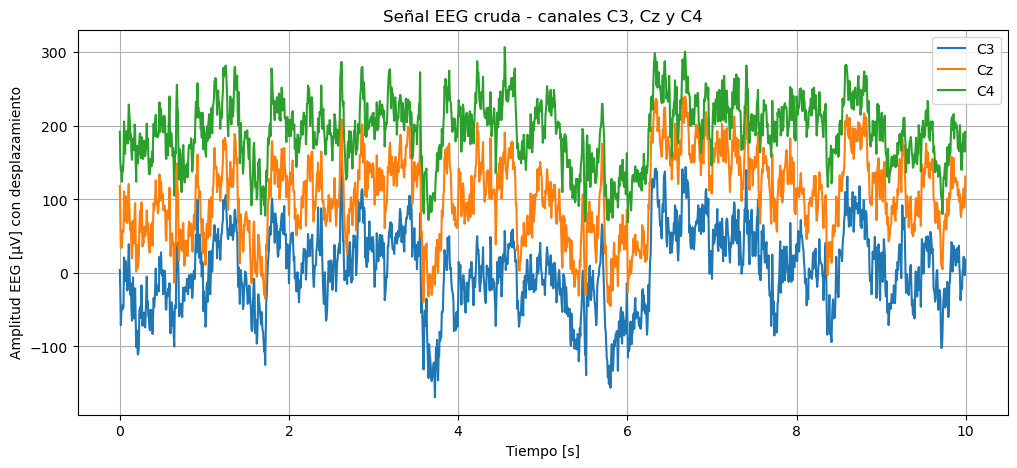

In [12]:
# ============================================================
# 11. VISUALIZAR SEÑAL CRUDA
# ============================================================

duracion_segundos = 10
sfreq = raw_canales.info["sfreq"]
n_muestras = int(duracion_segundos * sfreq)

data, times = raw_canales[:, :n_muestras]

# Pasamos de voltios a microvoltios para visualizar mejor
data_uv = data * 1e6

plt.figure(figsize=(12, 5))

offset = 100

for i, canal in enumerate(raw_canales.ch_names):
    plt.plot(times, data_uv[i] + i * offset, label=canal)

plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud EEG [µV] con desplazamiento")
plt.title("Señal EEG cruda - canales C3, Cz y C4")
plt.legend()
plt.grid(True)
plt.show()

In [13]:
# ============================================================
# 12. SEÑAL LISTA PARA FILTRAR
# ============================================================

raw_para_filtrar = raw_canales.copy()

print("Señal lista para aplicar filtros:")
print(raw_para_filtrar)

Señal lista para aplicar filtros:
<RawEDF | S001R04.edf, 3 x 20000 (125.0 s), ~476 KiB, data loaded>


In [14]:
# ============================================================
# 13. FILTRADO PASABANDA 8-30 Hz
# ============================================================

raw_filtrado = raw_para_filtrar.copy().filter(
    l_freq=8,
    h_freq=30,
    fir_design="firwin",
    verbose=False
)

print(raw_filtrado)

<RawEDF | S001R04.edf, 3 x 20000 (125.0 s), ~476 KiB, data loaded>


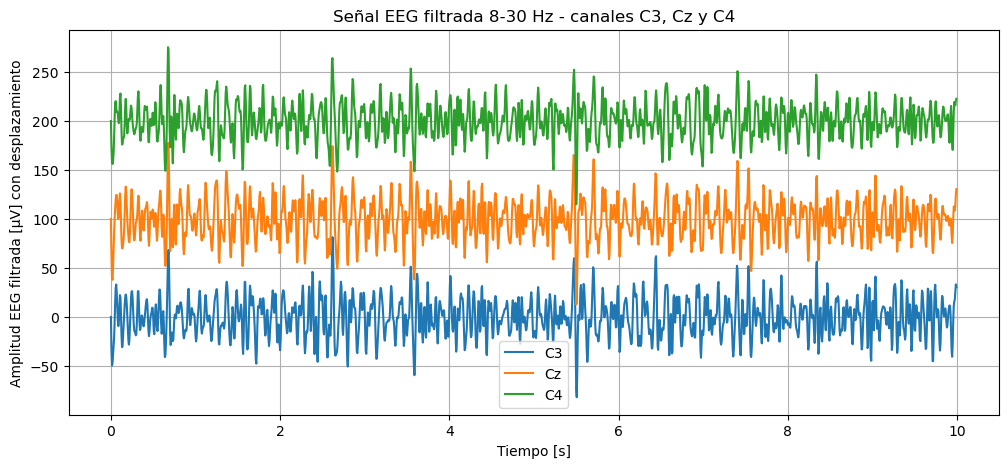

In [15]:
# Visualizar señal filtrada

data_filt, times = raw_filtrado[:, :n_muestras]
data_filt_uv = data_filt * 1e6

plt.figure(figsize=(12, 5))

for i, canal in enumerate(raw_filtrado.ch_names):
    plt.plot(times, data_filt_uv[i] + i * offset, label=canal)

plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud EEG filtrada [µV] con desplazamiento")
plt.title("Señal EEG filtrada 8-30 Hz - canales C3, Cz y C4")
plt.legend()
plt.grid(True)
plt.show()

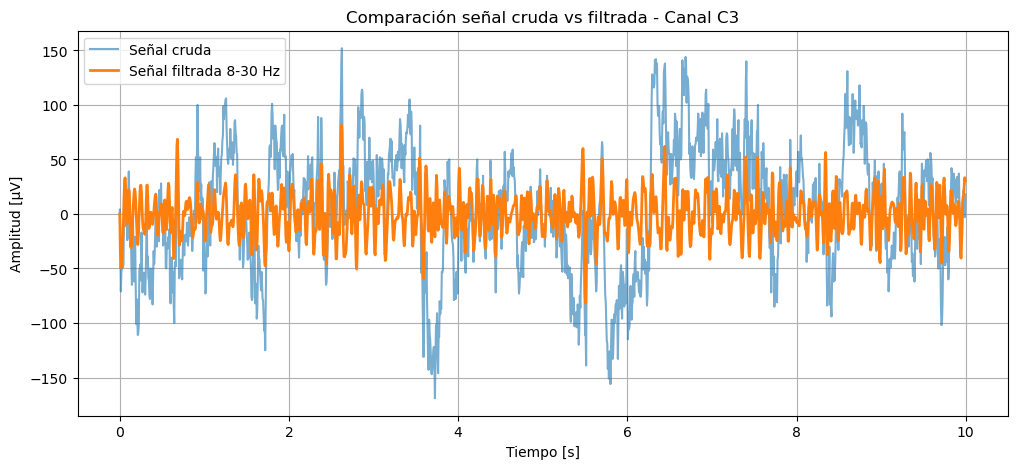

In [16]:
# Comparar señal cruda vs señal filtrada en C3

canal = "C3"
duracion_segundos = 10

sfreq = raw_canales.info["sfreq"]
n_muestras = int(duracion_segundos * sfreq)

data_cruda, times = raw_canales.copy().pick([canal])[:, :n_muestras]
data_filtrada, _ = raw_filtrado.copy().pick([canal])[:, :n_muestras]

plt.figure(figsize=(12, 5))

plt.plot(times, data_cruda[0] * 1e6, label="Señal cruda", alpha=0.6)
plt.plot(times, data_filtrada[0] * 1e6, label="Señal filtrada 8-30 Hz", linewidth=2)

plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud [µV]")
plt.title("Comparación señal cruda vs filtrada - Canal C3")
plt.legend()
plt.grid(True)
plt.show()

In [17]:
# ============================================================
# 14. CONVERTIR ANOTACIONES EN EVENTOS
# ============================================================

events, event_id_original = mne.events_from_annotations(
    raw_filtrado,
    verbose=False
)

print("Diccionario original de eventos:")
print(event_id_original)

print("\nPrimeros eventos:")
print(events[:10])

Diccionario original de eventos:
{'T0': 1, 'T1': 2, 'T2': 3}

Primeros eventos:
[[   0    0    1]
 [ 672    0    3]
 [1328    0    1]
 [2000    0    2]
 [2656    0    1]
 [3328    0    2]
 [3984    0    1]
 [4656    0    3]
 [5312    0    1]
 [5984    0    3]]


In [18]:
# ============================================================
# 15. DEFINIR CONDICIONES DE INTERÉS
# ============================================================

event_id = {
    "reposo": event_id_original["T0"],
    "mano_izquierda_imaginada": event_id_original["T1"],
    "mano_derecha_imaginada": event_id_original["T2"]
}

print(event_id)

{'reposo': 1, 'mano_izquierda_imaginada': 2, 'mano_derecha_imaginada': 3}


In [19]:
# ============================================================
# 16. CREAR ÉPOCAS DE EEG
# ============================================================

tmin = 0      # inicio del segmento justo en el evento
tmax = 4      # duración del segmento en segundos

epochs = mne.Epochs(
    raw_filtrado,
    events,
    event_id=event_id,
    tmin=tmin,
    tmax=tmax,
    baseline=None,
    preload=True,
    verbose=False
)

print(epochs)

<Epochs | 30 events (all good), 0 – 4 s (baseline off), ~458 KiB, data loaded,
 'reposo': 15
 'mano_izquierda_imaginada': 8
 'mano_derecha_imaginada': 7>


In [20]:
# ============================================================
# 17. CONTAR ÉPOCAS POR CONDICIÓN
# ============================================================

for condicion in event_id.keys():
    print(condicion, ":", len(epochs[condicion]))

reposo : 15
mano_izquierda_imaginada : 8
mano_derecha_imaginada : 7


C:\Users\ASUS\AppData\Local\Temp\ipykernel_24116\2386812825.py:7: RuntimeWarning: Channel locations not available. Disabling spatial colors.
  evoked.plot(


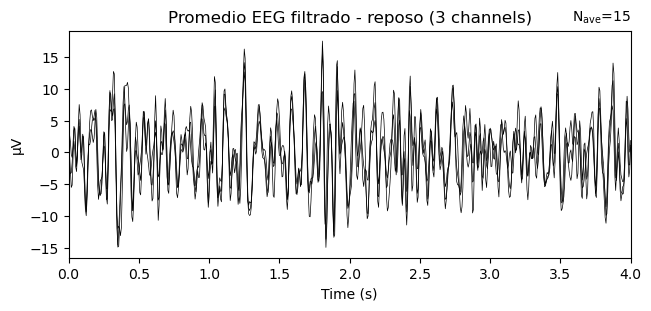

C:\Users\ASUS\AppData\Local\Temp\ipykernel_24116\2386812825.py:7: RuntimeWarning: Channel locations not available. Disabling spatial colors.
  evoked.plot(


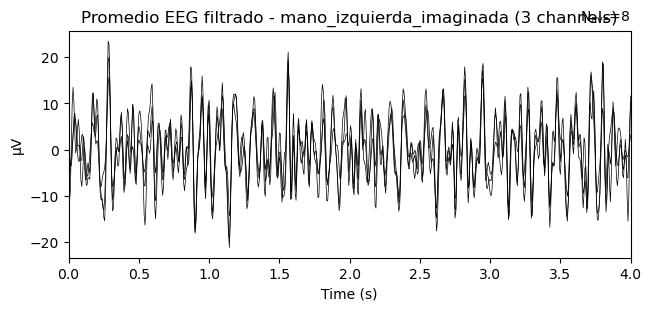

C:\Users\ASUS\AppData\Local\Temp\ipykernel_24116\2386812825.py:7: RuntimeWarning: Channel locations not available. Disabling spatial colors.
  evoked.plot(


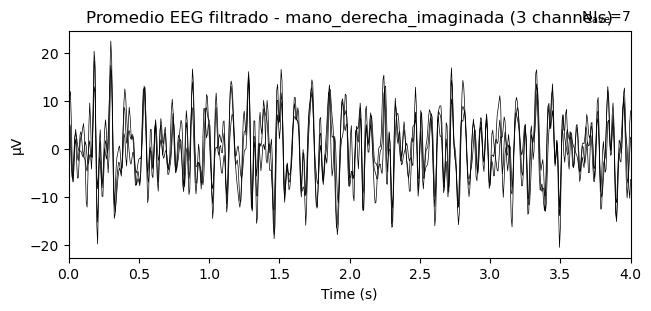

In [21]:
# ============================================================
# 18. PROMEDIO DE SEÑAL POR CONDICIÓN
# ============================================================

for condicion in event_id.keys():
    evoked = epochs[condicion].average()
    evoked.plot(
        picks=["C3", "Cz", "C4"],
        titles=f"Promedio EEG filtrado - {condicion}",
        spatial_colors=True
    )

In [22]:
# ============================================================
# 19. EXTRAER DATOS EN FORMATO NUMPY
# ============================================================

X = epochs.get_data()   # forma: épocas x canales x muestras
y = epochs.events[:, -1]

print('segmentos, canales, muestras')
print("Forma de X:", X.shape)
print("Forma de y:", y.shape)


segmentos, canales, muestras
Forma de X: (30, 3, 641)
Forma de y: (30,)


In [23]:
# ============================================================
# 20. DATAFRAME DE ÉPOCAS
# ============================================================

id_a_condicion = {v: k for k, v in event_id.items()}

df_epochs = pd.DataFrame({
    "epoca": np.arange(len(y)),
    "codigo_evento": y,
    "condicion": [id_a_condicion[codigo] for codigo in y]
})

df_epochs.head()


,epoca,codigo_evento,condicion
0,0,1,reposo
1,1,3,mano_derecha_imaginada
2,2,1,reposo
3,3,2,mano_izquierda_imaginada
4,4,1,reposo


In [24]:
df_epochs["condicion"].value_counts()

condicion
reposo                      15
mano_izquierda_imaginada     8
mano_derecha_imaginada       7
Name: count, dtype: int64

In [25]:
# ============================================================
# 21. GUARDAR ÉPOCAS PROCESADAS
# ============================================================

epochs.save(
    RESULTS_DIR / "S001R04_epocas_filtradas-epo.fif",
    overwrite=True
)

df_epochs.to_csv(
    RESULTS_DIR / "S001R04_info_epocas.csv",
    index=False
)

print("Épocas guardadas correctamente.")

Overwriting existing file.
Overwriting existing file.
Overwriting existing file.
Épocas guardadas correctamente.


In [26]:
# ============================================================
# 14. IMPORTAR FUNCIONES NECESARIAS
# ============================================================

from scipy.signal import welch, coherence
from math import factorial

In [27]:
# ============================================================
# 15. CREAR ÉPOCAS DESDE LA SEÑAL FILTRADA
# ============================================================

events, event_id_original = mne.events_from_annotations(
    raw_filtrado,
    verbose=False
)

print("Eventos encontrados:")
print(event_id_original)

event_id = {
    "reposo": event_id_original["T0"],
    "mano_izquierda_imaginada": event_id_original["T1"],
    "mano_derecha_imaginada": event_id_original["T2"]
}

tmin = 0
tmax = 4

epochs = mne.Epochs(
    raw_filtrado,
    events,
    event_id=event_id,
    tmin=tmin,
    tmax=tmax,
    baseline=None,
    preload=True,
    verbose=False
)

print(epochs)

for condicion in event_id.keys():
    print(condicion, ":", len(epochs[condicion]))

Eventos encontrados:
{'T0': 1, 'T1': 2, 'T2': 3}
<Epochs | 30 events (all good), 0 – 4 s (baseline off), ~458 KiB, data loaded,
 'reposo': 15
 'mano_izquierda_imaginada': 8
 'mano_derecha_imaginada': 7>
reposo : 15
mano_izquierda_imaginada : 8
mano_derecha_imaginada : 7


In [28]:
# ============================================================
# 16. DEFINIR BANDAS Y PARES DE CANALES
# ============================================================

bandas = {
    "mu": (8, 13),
    "beta": (13, 30)
}

pares_canales = [
    ("C3", "Cz"),
    ("C3", "C4"),
    ("Cz", "C4")
]

In [38]:
# ============================================================
# 17. FUNCIÓN PARA POTENCIA EN BANDAS CON WELCH
# ============================================================

def calcular_potencia_bandas(senal, sfreq, bandas):
    """
    Calcula la potencia de una señal en diferentes bandas usando Welch.

    Parámetros:
    -----------
    senal : array
        Señal de un canal en una época.
    sfreq : float
        Frecuencia de muestreo.
    bandas : dict
        Diccionario con bandas de frecuencia.

    Retorna:
    --------
    dict
        Potencia por banda.
    """

    nperseg = min(int(sfreq * 2), len(senal))

    freqs, psd = welch(
        senal,
        fs=sfreq,
        nperseg=nperseg
    )

    potencias = {}

    for nombre_banda, (fmin, fmax) in bandas.items():

        idx = (freqs >= fmin) & (freqs <= fmax)

        if np.sum(idx) == 0:
            potencias[nombre_banda] = np.nan
        else:
            potencias[nombre_banda] = np.trapz(psd[idx], freqs[idx])

    return potencias

In [30]:
# ============================================================
# 18. FUNCIÓN PARA PARÁMETROS DE HJORTH
# ============================================================

def calcular_hjorth(senal):
    """
    Calcula los parámetros de Hjorth:
    actividad, movilidad y complejidad.
    """

    senal = np.asarray(senal)

    actividad = np.var(senal)

    derivada = np.diff(senal)
    var_derivada = np.var(derivada)

    if actividad == 0:
        movilidad = np.nan
    else:
        movilidad = np.sqrt(var_derivada / actividad)

    segunda_derivada = np.diff(derivada)
    var_segunda_derivada = np.var(segunda_derivada)

    if var_derivada == 0:
        movilidad_derivada = np.nan
    else:
        movilidad_derivada = np.sqrt(var_segunda_derivada / var_derivada)

    if movilidad == 0 or np.isnan(movilidad):
        complejidad = np.nan
    else:
        complejidad = movilidad_derivada / movilidad

    return {
        "hjorth_actividad": actividad,
        "hjorth_movilidad": movilidad,
        "hjorth_complejidad": complejidad
    }

In [31]:
# ============================================================
# 19. FUNCIÓN PARA ENTROPÍA DE PERMUTACIÓN
# ============================================================

def calcular_entropia_permutacion(senal, orden=3, retardo=1):
    """
    Calcula la entropía de permutación normalizada.

    Una señal más regular tendrá menor entropía.
    Una señal más irregular tendrá mayor entropía.
    """

    senal = np.asarray(senal)

    n = len(senal)
    longitud_patron = retardo * (orden - 1) + 1

    if n < longitud_patron:
        return np.nan

    patrones = []

    for i in range(n - longitud_patron + 1):
        ventana = senal[i : i + longitud_patron : retardo]
        patron = tuple(np.argsort(ventana))
        patrones.append(patron)

    patrones = np.array(patrones)

    _, conteos = np.unique(
        patrones,
        axis=0,
        return_counts=True
    )

    probabilidades = conteos / np.sum(conteos)

    entropia = -np.sum(probabilidades * np.log2(probabilidades))

    entropia_maxima = np.log2(factorial(orden))

    entropia_normalizada = entropia / entropia_maxima

    return entropia_normalizada

In [32]:
# ============================================================
# 20. FUNCIÓN PARA COHERENCIA EN BANDAS
# ============================================================

def calcular_coherencia_bandas(senal_1, senal_2, sfreq, bandas):
    """
    Calcula la coherencia entre dos canales y la resume por bandas.
    """

    nperseg = min(int(sfreq * 2), len(senal_1))

    freqs, coh = coherence(
        senal_1,
        senal_2,
        fs=sfreq,
        nperseg=nperseg
    )

    coherencias = {}

    for nombre_banda, (fmin, fmax) in bandas.items():

        idx = (freqs >= fmin) & (freqs <= fmax)

        if np.sum(idx) == 0:
            coherencias[nombre_banda] = np.nan
        else:
            coherencias[nombre_banda] = np.mean(coh[idx])

    return coherencias

In [33]:
# ============================================================
# 21. EXTRAER CARACTERÍSTICAS DE TODAS LAS ÉPOCAS
# ============================================================

def extraer_caracteristicas_epochs(
    epochs,
    sujeto="S001",
    run="R04",
    tipo_tarea="imaginacion_motora",
    bandas=bandas,
    pares_canales=pares_canales
):
    """
    Extrae PSD, Hjorth, entropía y coherencia por época.

    Retorna un dataframe en formato largo.
    """

    datos = epochs.get_data()  # épocas x canales x muestras
    sfreq = epochs.info["sfreq"]
    canales = epochs.ch_names

    eventos_epocas = epochs.events[:, -1]
    id_a_condicion = {v: k for k, v in epochs.event_id.items()}

    resultados = []

    for idx_epoca in range(datos.shape[0]):

        codigo_evento = eventos_epocas[idx_epoca]
        condicion = id_a_condicion[codigo_evento]

        datos_epoca = datos[idx_epoca]

        # ====================================================
        # CARACTERÍSTICAS POR CANAL
        # ====================================================

        for idx_canal, canal in enumerate(canales):

            senal = datos_epoca[idx_canal]

            # ---------------------------
            # PSD en bandas
            # ---------------------------

            potencias = calcular_potencia_bandas(
                senal,
                sfreq,
                bandas
            )

            for banda, valor in potencias.items():

                resultados.append({
                    "sujeto": sujeto,
                    "run": run,
                    "tipo_tarea": tipo_tarea,
                    "epoca": idx_epoca,
                    "condicion": condicion,
                    "tipo_metrica": "frecuencia",
                    "metrica": "psd",
                    "canal": canal,
                    "par_canales": "",
                    "banda": banda,
                    "valor": valor
                })

            # ---------------------------
            # Hjorth
            # ---------------------------

            hjorth = calcular_hjorth(senal)

            for metrica, valor in hjorth.items():

                resultados.append({
                    "sujeto": sujeto,
                    "run": run,
                    "tipo_tarea": tipo_tarea,
                    "epoca": idx_epoca,
                    "condicion": condicion,
                    "tipo_metrica": "temporal",
                    "metrica": metrica,
                    "canal": canal,
                    "par_canales": "",
                    "banda": "",
                    "valor": valor
                })

            # ---------------------------
            # Entropía de permutación
            # ---------------------------

            entropia = calcular_entropia_permutacion(
                senal,
                orden=3,
                retardo=1
            )

            resultados.append({
                "sujeto": sujeto,
                "run": run,
                "tipo_tarea": tipo_tarea,
                "epoca": idx_epoca,
                "condicion": condicion,
                "tipo_metrica": "no_lineal",
                "metrica": "entropia_permutacion",
                "canal": canal,
                "par_canales": "",
                "banda": "",
                "valor": entropia
            })

        # ====================================================
        # COHERENCIA ENTRE PARES DE CANALES
        # ====================================================

        for canal_1, canal_2 in pares_canales:

            if canal_1 not in canales or canal_2 not in canales:
                continue

            idx_1 = canales.index(canal_1)
            idx_2 = canales.index(canal_2)

            senal_1 = datos_epoca[idx_1]
            senal_2 = datos_epoca[idx_2]

            coherencias = calcular_coherencia_bandas(
                senal_1,
                senal_2,
                sfreq,
                bandas
            )

            for banda, valor in coherencias.items():

                resultados.append({
                    "sujeto": sujeto,
                    "run": run,
                    "tipo_tarea": tipo_tarea,
                    "epoca": idx_epoca,
                    "condicion": condicion,
                    "tipo_metrica": "conectividad",
                    "metrica": "coherencia",
                    "canal": "",
                    "par_canales": f"{canal_1}-{canal_2}",
                    "banda": banda,
                    "valor": valor
                })

    df = pd.DataFrame(resultados)

    return df

In [40]:
# ============================================================
# IDENTIFICAR SUJETO Y RUN DEL ARCHIVO ACTUAL
# ============================================================

import re

nombre_archivo = archivo_prueba.name

coincidencia = re.search(r"(S\d{3})R(\d{2})", nombre_archivo)

if coincidencia:
    sujeto = coincidencia.group(1)
    run = "R" + coincidencia.group(2)
else:
    sujeto = "S001"
    run = "R04"

print("Archivo:", nombre_archivo)
print("Sujeto:", sujeto)
print("Run:", run)

Archivo: S001R04.edf
Sujeto: S001
Run: R04


In [41]:
# ============================================================
# 22.APLICAR EXTRACCIÓN DE CARACTERÍSTICAS
# ============================================================

df_caracteristicas = extraer_caracteristicas_epochs(
    epochs=epochs,
    sujeto=sujeto,
    run=run,
    tipo_tarea="imaginacion_motora",
    bandas=bandas,
    pares_canales=pares_canales
)

df_caracteristicas.head()

,sujeto,run,tipo_tarea,epoca,condicion,tipo_metrica,metrica,canal,par_canales,banda,valor
0,S001,R04,imaginacion_motora,0,reposo,frecuencia,psd,C3,,mu,1.807449e-10
1,S001,R04,imaginacion_motora,0,reposo,frecuencia,psd,C3,,beta,1.571967e-10
2,S001,R04,imaginacion_motora,0,reposo,temporal,hjorth_actividad,C3,,,4.049913e-10
3,S001,R04,imaginacion_motora,0,reposo,temporal,hjorth_movilidad,C3,,,5.890676e-01
4,S001,R04,imaginacion_motora,0,reposo,temporal,hjorth_complejidad,C3,,,1.334187e+00


In [42]:
# ============================================================
# 23. IDENTIFICAR SUJETO Y RUN DEL ARCHIVO ACTUAL
# ============================================================

nombre_archivo = archivo_prueba.name

coincidencia = re.search(r"(S\d{3})R(\d{2})", nombre_archivo)

if coincidencia:
    sujeto = coincidencia.group(1)
    run = "R" + coincidencia.group(2)
else:
    sujeto = "S001"
    run = "R04"

print("Sujeto:", sujeto)
print("Run:", run)

Sujeto: S001
Run: R04


In [43]:
# ============================================================
# 24. DEFINIR BANDAS Y PARES DE CANALES
# ============================================================

bandas = {
    "mu": (8, 13),
    "beta": (13, 30)
}

pares_canales = [
    ("C3", "Cz"),
    ("C3", "C4"),
    ("Cz", "C4")
]

print("Bandas:", bandas)
print("Pares de canales:", pares_canales)

Bandas: {'mu': (8, 13), 'beta': (13, 30)}
Pares de canales: [('C3', 'Cz'), ('C3', 'C4'), ('Cz', 'C4')]


In [51]:
# ============================================================
# 25. FUNCIÓN PARA CALCULAR POTENCIA EN BANDAS
# ============================================================

def calcular_potencia_bandas(senal, sfreq, bandas):
    """
    Calcula la potencia de una señal EEG en bandas de frecuencia
    usando el método de Welch.

    Parámetros:
    -----------
    senal : array
        Señal EEG de un canal en una época.
    sfreq : float
        Frecuencia de muestreo.
    bandas : dict
        Diccionario con las bandas de frecuencia.

    Retorna:
    --------
    potencias : dict
        Potencia calculada para cada banda.
    """

    nperseg = min(int(sfreq * 2), len(senal))

    freqs, psd = welch(
        senal,
        fs=sfreq,
        nperseg=nperseg
    )

    potencias = {}

    for nombre_banda, (fmin, fmax) in bandas.items():

        indices_banda = (freqs >= fmin) & (freqs <= fmax)

        if np.sum(indices_banda) == 0:
            potencias[nombre_banda] = np.nan
        else:
            potencias[nombre_banda] = np.trapz(
                psd[indices_banda],
                freqs[indices_banda]
            )

    return potencias

In [45]:
# ============================================================
# 26. FUNCIÓN PARA CALCULAR PARÁMETROS DE HJORTH
# ============================================================

def calcular_hjorth(senal):
    """
    Calcula los parámetros de Hjorth:
    actividad, movilidad y complejidad.
    """

    senal = np.asarray(senal)

    actividad = np.var(senal)

    primera_derivada = np.diff(senal)
    var_primera_derivada = np.var(primera_derivada)

    if actividad == 0:
        movilidad = np.nan
    else:
        movilidad = np.sqrt(var_primera_derivada / actividad)

    segunda_derivada = np.diff(primera_derivada)
    var_segunda_derivada = np.var(segunda_derivada)

    if var_primera_derivada == 0:
        movilidad_derivada = np.nan
    else:
        movilidad_derivada = np.sqrt(
            var_segunda_derivada / var_primera_derivada
        )

    if movilidad == 0 or np.isnan(movilidad):
        complejidad = np.nan
    else:
        complejidad = movilidad_derivada / movilidad

    return {
        "hjorth_actividad": actividad,
        "hjorth_movilidad": movilidad,
        "hjorth_complejidad": complejidad
    }

In [46]:
# ============================================================
# 27. FUNCIÓN PARA CALCULAR ENTROPÍA DE PERMUTACIÓN
# ============================================================

def calcular_entropia_permutacion(senal, orden=3, retardo=1):
    """
    Calcula la entropía de permutación normalizada.

    La entropía de permutación mide qué tan irregular o compleja
    es la señal.
    """

    senal = np.asarray(senal)
    n = len(senal)

    longitud_patron = retardo * (orden - 1) + 1

    if n < longitud_patron:
        return np.nan

    patrones = []

    for i in range(n - longitud_patron + 1):
        ventana = senal[i : i + longitud_patron : retardo]
        patron = tuple(np.argsort(ventana))
        patrones.append(patron)

    patrones = np.array(patrones)

    _, conteos = np.unique(
        patrones,
        axis=0,
        return_counts=True
    )

    probabilidades = conteos / np.sum(conteos)

    entropia = -np.sum(probabilidades * np.log2(probabilidades))

    entropia_maxima = np.log2(factorial(orden))

    entropia_normalizada = entropia / entropia_maxima

    return entropia_normalizada

In [47]:
# ============================================================
# 28. FUNCIÓN PARA CALCULAR COHERENCIA EN BANDAS
# ============================================================

def calcular_coherencia_bandas(senal_1, senal_2, sfreq, bandas):
    """
    Calcula la coherencia entre dos señales EEG y la resume
    por bandas de frecuencia.
    """

    nperseg = min(int(sfreq * 2), len(senal_1))

    freqs, coh = coherence(
        senal_1,
        senal_2,
        fs=sfreq,
        nperseg=nperseg
    )

    coherencias = {}

    for nombre_banda, (fmin, fmax) in bandas.items():

        indices_banda = (freqs >= fmin) & (freqs <= fmax)

        if np.sum(indices_banda) == 0:
            coherencias[nombre_banda] = np.nan
        else:
            coherencias[nombre_banda] = np.mean(coh[indices_banda])

    return coherencias

In [48]:
# ============================================================
# 29. FUNCIÓN GENERAL DE EXTRACCIÓN DE CARACTERÍSTICAS
# ============================================================

def extraer_caracteristicas_epochs(
    epochs,
    sujeto,
    run,
    tipo_tarea,
    bandas,
    pares_canales
):
    """
    Extrae características por época y por condición.

    Características calculadas:
    - Potencia en bandas mu y beta.
    - Parámetros de Hjorth.
    - Entropía de permutación.
    - Coherencia entre pares de canales.

    Retorna:
    --------
    df_caracteristicas : DataFrame
        Dataframe en formato largo.
    """

    datos = epochs.get_data()  # épocas x canales x muestras
    sfreq = epochs.info["sfreq"]
    canales = epochs.ch_names

    eventos_epocas = epochs.events[:, -1]
    id_a_condicion = {v: k for k, v in epochs.event_id.items()}

    resultados = []

    for idx_epoca in range(datos.shape[0]):

        codigo_evento = eventos_epocas[idx_epoca]
        condicion = id_a_condicion[codigo_evento]

        datos_epoca = datos[idx_epoca]

        # ====================================================
        # CARACTERÍSTICAS POR CANAL
        # ====================================================

        for idx_canal, canal in enumerate(canales):

            senal = datos_epoca[idx_canal]

            # ----------------------------
            # Potencia en bandas
            # ----------------------------

            potencias = calcular_potencia_bandas(
                senal,
                sfreq,
                bandas
            )

            for banda, valor in potencias.items():

                resultados.append({
                    "sujeto": sujeto,
                    "run": run,
                    "tipo_tarea": tipo_tarea,
                    "epoca": idx_epoca,
                    "condicion": condicion,
                    "tipo_metrica": "frecuencia",
                    "metrica": "psd",
                    "canal": canal,
                    "par_canales": "",
                    "banda": banda,
                    "valor": valor
                })

            # ----------------------------
            # Hjorth
            # ----------------------------

            hjorth = calcular_hjorth(senal)

            for nombre_metrica, valor in hjorth.items():

                resultados.append({
                    "sujeto": sujeto,
                    "run": run,
                    "tipo_tarea": tipo_tarea,
                    "epoca": idx_epoca,
                    "condicion": condicion,
                    "tipo_metrica": "temporal",
                    "metrica": nombre_metrica,
                    "canal": canal,
                    "par_canales": "",
                    "banda": "",
                    "valor": valor
                })

            # ----------------------------
            # Entropía de permutación
            # ----------------------------

            entropia = calcular_entropia_permutacion(
                senal,
                orden=3,
                retardo=1
            )

            resultados.append({
                "sujeto": sujeto,
                "run": run,
                "tipo_tarea": tipo_tarea,
                "epoca": idx_epoca,
                "condicion": condicion,
                "tipo_metrica": "no_lineal",
                "metrica": "entropia_permutacion",
                "canal": canal,
                "par_canales": "",
                "banda": "",
                "valor": entropia
            })

        # ====================================================
        # COHERENCIA ENTRE PARES DE CANALES
        # ====================================================

        for canal_1, canal_2 in pares_canales:

            if canal_1 not in canales or canal_2 not in canales:
                continue

            idx_1 = canales.index(canal_1)
            idx_2 = canales.index(canal_2)

            senal_1 = datos_epoca[idx_1]
            senal_2 = datos_epoca[idx_2]

            coherencias = calcular_coherencia_bandas(
                senal_1,
                senal_2,
                sfreq,
                bandas
            )

            for banda, valor in coherencias.items():

                resultados.append({
                    "sujeto": sujeto,
                    "run": run,
                    "tipo_tarea": tipo_tarea,
                    "epoca": idx_epoca,
                    "condicion": condicion,
                    "tipo_metrica": "conectividad",
                    "metrica": "coherencia",
                    "canal": "",
                    "par_canales": f"{canal_1}-{canal_2}",
                    "banda": banda,
                    "valor": valor
                })

    df_caracteristicas = pd.DataFrame(resultados)

    return df_caracteristicas

In [52]:
# ============================================================
# 30. APLICAR EXTRACCIÓN DE CARACTERÍSTICAS
# ============================================================

df_caracteristicas = extraer_caracteristicas_epochs(
    epochs=epochs,
    sujeto=sujeto,
    run=run,
    tipo_tarea="imaginacion_motora",
    bandas=bandas,
    pares_canales=pares_canales
)

df_caracteristicas.head()

,sujeto,run,tipo_tarea,epoca,condicion,tipo_metrica,metrica,canal,par_canales,banda,valor
0,S001,R04,imaginacion_motora,0,reposo,frecuencia,psd,C3,,mu,1.807449e-10
1,S001,R04,imaginacion_motora,0,reposo,frecuencia,psd,C3,,beta,1.571967e-10
2,S001,R04,imaginacion_motora,0,reposo,temporal,hjorth_actividad,C3,,,4.049913e-10
3,S001,R04,imaginacion_motora,0,reposo,temporal,hjorth_movilidad,C3,,,5.890676e-01
4,S001,R04,imaginacion_motora,0,reposo,temporal,hjorth_complejidad,C3,,,1.334187e+00


In [53]:
# Revisar resumen del dataframe

print("Cantidad total de filas:", len(df_caracteristicas))

print("\nCantidad por métrica:")
print(df_caracteristicas["metrica"].value_counts())

print("\nCantidad por condición:")
print(df_caracteristicas["condicion"].value_counts())

df_caracteristicas.head(15)

Cantidad total de filas: 720

Cantidad por métrica:
metrica
psd                     180
coherencia              180
hjorth_actividad         90
hjorth_movilidad         90
hjorth_complejidad       90
entropia_permutacion     90
Name: count, dtype: int64

Cantidad por condición:
condicion
reposo                      360
mano_izquierda_imaginada    192
mano_derecha_imaginada      168
Name: count, dtype: int64


,sujeto,run,tipo_tarea,epoca,condicion,tipo_metrica,metrica,canal,par_canales,banda,valor
0,S001,R04,imaginacion_motora,0,reposo,frecuencia,psd,C3,,mu,1.807449e-10
1,S001,R04,imaginacion_motora,0,reposo,frecuencia,psd,C3,,beta,1.571967e-10
2,S001,R04,imaginacion_motora,0,reposo,temporal,hjorth_actividad,C3,,,4.049913e-10
3,S001,R04,imaginacion_motora,0,reposo,temporal,hjorth_movilidad,C3,,,5.890676e-01
4,S001,R04,imaginacion_motora,0,reposo,temporal,hjorth_complejidad,C3,,,1.334187e+00
5,S001,R04,imaginacion_motora,0,reposo,no_lineal,entropia_permutacion,C3,,,8.044480e-01
6,S001,R04,imaginacion_motora,0,reposo,frecuencia,psd,Cz,,mu,2.309914e-10
7,S001,R04,imaginacion_motora,0,reposo,frecuencia,psd,Cz,,beta,1.575416e-10
8,S001,R04,imaginacion_motora,0,reposo,temporal,hjorth_actividad,Cz,,,4.698366e-10
9,S001,R04,imaginacion_motora,0,reposo,temporal,hjorth_movilidad,Cz,,,5.804225e-01


In [54]:
# ============================================================
# 31. GUARDAR DATAFRAME DE CARACTERÍSTICAS
# ============================================================

ruta_caracteristicas = RESULTS_DIR / f"caracteristicas_{sujeto}_{run}.csv"

df_caracteristicas.to_csv(
    ruta_caracteristicas,
    index=False
)

print("Características guardadas en:")
print(ruta_caracteristicas.resolve())

Características guardadas en:
C:\Users\ASUS\Downloads\resultados\caracteristicas_S001_R04.csv


In [55]:
# ============================================================
# 32. CREAR NOMBRE DE CADA CARACTERÍSTICA
# ============================================================

def crear_nombre_feature(fila):
    """
    Crea un nombre único para cada característica.
    """

    if fila["canal"] != "":
        ubicacion = fila["canal"]
    else:
        ubicacion = fila["par_canales"]

    if fila["banda"] != "":
        nombre = f"{fila['metrica']}_{ubicacion}_{fila['banda']}"
    else:
        nombre = f"{fila['metrica']}_{ubicacion}"

    return nombre

In [56]:
df_features = df_caracteristicas.copy()

df_features["feature"] = df_features.apply(
    crear_nombre_feature,
    axis=1
)

df_features.head()

,sujeto,run,tipo_tarea,epoca,condicion,tipo_metrica,metrica,canal,par_canales,banda,valor,feature
0,S001,R04,imaginacion_motora,0,reposo,frecuencia,psd,C3,,mu,1.807449e-10,psd_C3_mu
1,S001,R04,imaginacion_motora,0,reposo,frecuencia,psd,C3,,beta,1.571967e-10,psd_C3_beta
2,S001,R04,imaginacion_motora,0,reposo,temporal,hjorth_actividad,C3,,,4.049913e-10,hjorth_actividad_C3
3,S001,R04,imaginacion_motora,0,reposo,temporal,hjorth_movilidad,C3,,,5.890676e-01,hjorth_movilidad_C3
4,S001,R04,imaginacion_motora,0,reposo,temporal,hjorth_complejidad,C3,,,1.334187e+00,hjorth_complejidad_C3


In [57]:
# ============================================================
# 33. DATAFRAME ANCHO
# ============================================================

df_features_wide = df_features.pivot_table(
    index=["sujeto", "run", "tipo_tarea", "epoca", "condicion"],
    columns="feature",
    values="valor"
).reset_index()

df_features_wide.head()

feature,sujeto,run,tipo_tarea,epoca,condicion,coherencia_C3-C4_beta,coherencia_C3-C4_mu,coherencia_C3-Cz_beta,coherencia_C3-Cz_mu,coherencia_Cz-C4_beta,...,hjorth_complejidad_Cz,hjorth_movilidad_C3,hjorth_movilidad_C4,hjorth_movilidad_Cz,psd_C3_beta,psd_C3_mu,psd_C4_beta,psd_C4_mu,psd_Cz_beta,psd_Cz_mu
0,S001,R04,imaginacion_motora,0,reposo,0.548739,0.757301,0.729471,0.866048,0.782158,...,1.395894,0.589068,0.589703,0.580423,1.571967e-10,1.807449e-10,1.326785e-10,1.820803e-10,1.575416e-10,2.309914e-10
1,S001,R04,imaginacion_motora,1,mano_derecha_imaginada,0.566131,0.672162,0.830022,0.828018,0.699684,...,1.399078,0.607403,0.606173,0.586667,1.636234e-10,1.608446e-10,1.419351e-10,1.418678e-10,1.611075e-10,1.800309e-10
2,S001,R04,imaginacion_motora,2,reposo,0.730795,0.718902,0.887473,0.847520,0.802928,...,1.359751,0.641720,0.602563,0.600881,2.217399e-10,1.649009e-10,1.369009e-10,1.043773e-10,1.998830e-10,1.619194e-10
3,S001,R04,imaginacion_motora,3,mano_izquierda_imaginada,0.592032,0.663038,0.817542,0.746038,0.800610,...,1.416300,0.624490,0.618020,0.617327,1.379234e-10,8.367593e-11,1.038181e-10,5.920273e-11,1.236169e-10,7.785471e-11
4,S001,R04,imaginacion_motora,4,reposo,0.621712,0.439694,0.762544,0.758907,0.784984,...,1.336435,0.578894,0.599775,0.596866,2.004874e-10,1.503950e-10,1.532310e-10,1.389338e-10,1.942459e-10,1.284300e-10


In [58]:
# ============================================================
# 34. GUARDAR DATAFRAME ANCHO
# ============================================================

ruta_features_wide = RESULTS_DIR / f"features_wide_{sujeto}_{run}.csv"

df_features_wide.to_csv(
    ruta_features_wide,
    index=False
)

print("Dataframe para clasificación guardado en:")
print(ruta_features_wide.resolve())

Dataframe para clasificación guardado en:
C:\Users\ASUS\Downloads\resultados\features_wide_S001_R04.csv


# DE ACÁ HACIA ABAJO YA SERÁ CON TODOS LOS SUJETOS

In [59]:
# ============================================================
# 35. FUNCIÓN PARA PROCESAR UN ARCHIVO EDF
# ============================================================

def procesar_archivo_edf(
    ruta_archivo,
    canales_interes=["C3", "Cz", "C4"],
    bandas=bandas,
    pares_canales=pares_canales,
    tmin=0,
    tmax=4
):
    """
    Procesa un archivo EDF completo:
    1. Lee la señal.
    2. Limpia nombres de canales.
    3. Selecciona canales de interés.
    4. Filtra entre 8 y 30 Hz.
    5. Segmenta por eventos T0, T1 y T2.
    6. Extrae características por época.

    Retorna:
    --------
    df_caracteristicas : DataFrame
        DataFrame largo con las características extraídas.
    """

    # --------------------------------------------------------
    # Identificar sujeto y run desde el nombre del archivo
    # --------------------------------------------------------

    nombre_archivo = ruta_archivo.name

    coincidencia = re.search(r"(S\d{3})R(\d{2})", nombre_archivo)

    if coincidencia:
        sujeto = coincidencia.group(1)
        run = "R" + coincidencia.group(2)
    else:
        sujeto = "desconocido"
        run = "desconocido"

    # --------------------------------------------------------
    # Leer archivo EDF
    # --------------------------------------------------------

    raw = mne.io.read_raw_edf(
        ruta_archivo,
        preload=True,
        verbose=False
    )

    raw = limpiar_nombres_canales(raw)

    # --------------------------------------------------------
    # Verificar canales disponibles
    # --------------------------------------------------------

    canales_disponibles = [
        canal for canal in canales_interes
        if canal in raw.ch_names
    ]

    if len(canales_disponibles) < 2:
        print(f"Archivo omitido por falta de canales: {nombre_archivo}")
        return None

    raw = raw.pick(canales_disponibles)

    # --------------------------------------------------------
    # Filtrar señal
    # --------------------------------------------------------

    raw_filtrado = raw.copy().filter(
        l_freq=8,
        h_freq=30,
        fir_design="firwin",
        verbose=False
    )

    # --------------------------------------------------------
    # Crear eventos desde anotaciones
    # --------------------------------------------------------

    events, event_id_original = mne.events_from_annotations(
        raw_filtrado,
        verbose=False
    )

    eventos_requeridos = ["T0", "T1", "T2"]

    for evento in eventos_requeridos:
        if evento not in event_id_original:
            print(f"Archivo omitido porque no tiene {evento}: {nombre_archivo}")
            return None

    event_id = {
        "reposo": event_id_original["T0"],
        "mano_izquierda_imaginada": event_id_original["T1"],
        "mano_derecha_imaginada": event_id_original["T2"]
    }

    # --------------------------------------------------------
    # Crear épocas
    # --------------------------------------------------------

    epochs = mne.Epochs(
        raw_filtrado,
        events,
        event_id=event_id,
        tmin=tmin,
        tmax=tmax,
        baseline=None,
        preload=True,
        verbose=False
    )

    if len(epochs) == 0:
        print(f"Archivo omitido porque no generó épocas: {nombre_archivo}")
        return None

    # --------------------------------------------------------
    # Extraer características
    # --------------------------------------------------------

    df_caracteristicas = extraer_caracteristicas_epochs(
        epochs=epochs,
        sujeto=sujeto,
        run=run,
        tipo_tarea="imaginacion_motora",
        bandas=bandas,
        pares_canales=pares_canales
    )

    return df_caracteristicas

In [60]:
# ============================================================
# 36. PROCESAR TODOS LOS ARCHIVOS DE IMAGINACIÓN MOTORA
# ============================================================

resultados_todos = []

for archivo in tqdm(edf_interes, desc="Procesando archivos EDF"):

    df_archivo = procesar_archivo_edf(
        ruta_archivo=archivo,
        canales_interes=["C3", "Cz", "C4"],
        bandas=bandas,
        pares_canales=pares_canales,
        tmin=0,
        tmax=4
    )

    if df_archivo is not None:
        resultados_todos.append(df_archivo)

print("Cantidad de archivos procesados correctamente:", len(resultados_todos))

Procesando archivos EDF:  91%|█████████ | 297/327 [04:05<00:13,  2.15it/s]C:\Users\ASUS\AppData\Local\Temp\ipykernel_24116\1756502225.py:47: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw = mne.io.read_raw_edf(
Procesando archivos EDF:  91%|█████████ | 298/327 [04:06<00:14,  2.06it/s]C:\Users\ASUS\AppData\Local\Temp\ipykernel_24116\1756502225.py:47: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw = mne.io.read_raw_edf(
Procesando archivos EDF:  91%|█████████▏| 299/327 [04:06<00:13,  2.05it/s]C:\Users\ASUS\AppData\Local\Temp\ipykernel_24116\1756502225.py:47: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw = mne.io.read_raw_edf(
Procesando archivos EDF: 100%|██████████| 327/327 [04:19<00:00,  1.26it/s]

Cantidad de archivos procesados correctamente: 327


In [61]:
# ============================================================
# 37. UNIR RESULTADOS DE TODOS LOS ARCHIVOS
# ============================================================

df_caracteristicas_todos = pd.concat(
    resultados_todos,
    ignore_index=True
)

print("Forma del dataframe final:")
print(df_caracteristicas_todos.shape)

display(df_caracteristicas_todos.head())

Forma del dataframe final:
(235584, 11)


,sujeto,run,tipo_tarea,epoca,condicion,tipo_metrica,metrica,canal,par_canales,banda,valor
0,S001,R04,imaginacion_motora,0,reposo,frecuencia,psd,C3,,mu,1.807449e-10
1,S001,R04,imaginacion_motora,0,reposo,frecuencia,psd,C3,,beta,1.571967e-10
2,S001,R04,imaginacion_motora,0,reposo,temporal,hjorth_actividad,C3,,,4.049913e-10
3,S001,R04,imaginacion_motora,0,reposo,temporal,hjorth_movilidad,C3,,,5.890676e-01
4,S001,R04,imaginacion_motora,0,reposo,temporal,hjorth_complejidad,C3,,,1.334187e+00


In [62]:
# ============================================================
# 38. GUARDAR DATAFRAME LARGO FINAL
# ============================================================

ruta_caracteristicas_todos = RESULTS_DIR / "caracteristicas_todos_largo.csv"

df_caracteristicas_todos.to_csv(
    ruta_caracteristicas_todos,
    index=False
)

print("Dataframe largo guardado en:")
print(ruta_caracteristicas_todos.resolve())

Dataframe largo guardado en:
C:\Users\ASUS\Downloads\resultados\caracteristicas_todos_largo.csv


In [63]:
# ============================================================
# 39. CREAR DATAFRAME ANCHO DE TODOS LOS SUJETOS
# ============================================================

df_features_todos = df_caracteristicas_todos.copy()

df_features_todos["feature"] = df_features_todos.apply(
    crear_nombre_feature,
    axis=1
)

df_features_wide_todos = df_features_todos.pivot_table(
    index=["sujeto", "run", "tipo_tarea", "epoca", "condicion"],
    columns="feature",
    values="valor"
).reset_index()

print("Forma del dataframe ancho final:")
print(df_features_wide_todos.shape)

display(df_features_wide_todos.head())

Forma del dataframe ancho final:
(9816, 29)


feature,sujeto,run,tipo_tarea,epoca,condicion,coherencia_C3-C4_beta,coherencia_C3-C4_mu,coherencia_C3-Cz_beta,coherencia_C3-Cz_mu,coherencia_Cz-C4_beta,...,hjorth_complejidad_Cz,hjorth_movilidad_C3,hjorth_movilidad_C4,hjorth_movilidad_Cz,psd_C3_beta,psd_C3_mu,psd_C4_beta,psd_C4_mu,psd_Cz_beta,psd_Cz_mu
0,S001,R04,imaginacion_motora,0,reposo,0.548739,0.757301,0.729471,0.866048,0.782158,...,1.395894,0.589068,0.589703,0.580423,1.571967e-10,1.807449e-10,1.326785e-10,1.820803e-10,1.575416e-10,2.309914e-10
1,S001,R04,imaginacion_motora,1,mano_derecha_imaginada,0.566131,0.672162,0.830022,0.828018,0.699684,...,1.399078,0.607403,0.606173,0.586667,1.636234e-10,1.608446e-10,1.419351e-10,1.418678e-10,1.611075e-10,1.800309e-10
2,S001,R04,imaginacion_motora,2,reposo,0.730795,0.718902,0.887473,0.847520,0.802928,...,1.359751,0.641720,0.602563,0.600881,2.217399e-10,1.649009e-10,1.369009e-10,1.043773e-10,1.998830e-10,1.619194e-10
3,S001,R04,imaginacion_motora,3,mano_izquierda_imaginada,0.592032,0.663038,0.817542,0.746038,0.800610,...,1.416300,0.624490,0.618020,0.617327,1.379234e-10,8.367593e-11,1.038181e-10,5.920273e-11,1.236169e-10,7.785471e-11
4,S001,R04,imaginacion_motora,4,reposo,0.621712,0.439694,0.762544,0.758907,0.784984,...,1.336435,0.578894,0.599775,0.596866,2.004874e-10,1.503950e-10,1.532310e-10,1.389338e-10,1.942459e-10,1.284300e-10


In [64]:
# ============================================================
# 40. GUARDAR DATAFRAME ANCHO FINAL
# ============================================================

ruta_features_wide_todos = RESULTS_DIR / "features_wide_todos.csv"

df_features_wide_todos.to_csv(
    ruta_features_wide_todos,
    index=False
)

print("Dataframe ancho guardado en:")
print(ruta_features_wide_todos.resolve())

Dataframe ancho guardado en:
C:\Users\ASUS\Downloads\resultados\features_wide_todos.csv


In [65]:
print("Cantidad de archivos EDF de interés:", len(edf_interes))

for archivo in edf_interes[:15]:
    print(archivo.name)

Cantidad de archivos EDF de interés: 327
S001R04.edf
S001R08.edf
S001R12.edf
S002R04.edf
S002R08.edf
S002R12.edf
S003R04.edf
S003R08.edf
S003R12.edf
S004R04.edf
S004R08.edf
S004R12.edf
S005R04.edf
S005R08.edf
S005R12.edf


In [66]:
print("Sujetos procesados:")
print(df_caracteristicas_todos["sujeto"].nunique())

print("\nLista de sujetos:")
print(sorted(df_caracteristicas_todos["sujeto"].unique()))

print("\nRuns procesados:")
print(df_caracteristicas_todos["run"].value_counts())

print("\nCondiciones:")
print(df_caracteristicas_todos["condicion"].value_counts())

Sujetos procesados:
109

Lista de sujetos:
['S001', 'S002', 'S003', 'S004', 'S005', 'S006', 'S007', 'S008', 'S009', 'S010', 'S011', 'S012', 'S013', 'S014', 'S015', 'S016', 'S017', 'S018', 'S019', 'S020', 'S021', 'S022', 'S023', 'S024', 'S025', 'S026', 'S027', 'S028', 'S029', 'S030', 'S031', 'S032', 'S033', 'S034', 'S035', 'S036', 'S037', 'S038', 'S039', 'S040', 'S041', 'S042', 'S043', 'S044', 'S045', 'S046', 'S047', 'S048', 'S049', 'S050', 'S051', 'S052', 'S053', 'S054', 'S055', 'S056', 'S057', 'S058', 'S059', 'S060', 'S061', 'S062', 'S063', 'S064', 'S065', 'S066', 'S067', 'S068', 'S069', 'S070', 'S071', 'S072', 'S073', 'S074', 'S075', 'S076', 'S077', 'S078', 'S079', 'S080', 'S081', 'S082', 'S083', 'S084', 'S085', 'S086', 'S087', 'S088', 'S089', 'S090', 'S091', 'S092', 'S093', 'S094', 'S095', 'S096', 'S097', 'S098', 'S099', 'S100', 'S101', 'S102', 'S103', 'S104', 'S105', 'S106', 'S107', 'S108', 'S109']

Runs procesados:
run
R04    78624
R12    78552
R08    78408
Name: count, dtype: int

## HASTA ACÁ LLEGÓ LA PARTE DE PROGRAMACIÓN. AHORA VAMOS A EMPEZAR A REALIZAR GRÁFICAS Y DEMÁS NECESARIOS PARA EL ANÁLISIS DEL PROYECTO

In [67]:
# ============================================================
# 41. VERIFICAR DATAFRAME FINAL PARA ANÁLISIS
# ============================================================

print("Forma del dataframe ancho final:")
print(df_features_wide_todos.shape)

print("\nPrimeras filas:")
display(df_features_wide_todos.head())

print("\nCondiciones disponibles:")
print(df_features_wide_todos["condicion"].value_counts())

print("\nSujetos disponibles:")
print(df_features_wide_todos["sujeto"].nunique())

print("\nRuns disponibles:")
print(df_features_wide_todos["run"].value_counts())

Forma del dataframe ancho final:
(9816, 29)

Primeras filas:


feature,sujeto,run,tipo_tarea,epoca,condicion,coherencia_C3-C4_beta,coherencia_C3-C4_mu,coherencia_C3-Cz_beta,coherencia_C3-Cz_mu,coherencia_Cz-C4_beta,...,hjorth_complejidad_Cz,hjorth_movilidad_C3,hjorth_movilidad_C4,hjorth_movilidad_Cz,psd_C3_beta,psd_C3_mu,psd_C4_beta,psd_C4_mu,psd_Cz_beta,psd_Cz_mu
0,S001,R04,imaginacion_motora,0,reposo,0.548739,0.757301,0.729471,0.866048,0.782158,...,1.395894,0.589068,0.589703,0.580423,1.571967e-10,1.807449e-10,1.326785e-10,1.820803e-10,1.575416e-10,2.309914e-10
1,S001,R04,imaginacion_motora,1,mano_derecha_imaginada,0.566131,0.672162,0.830022,0.828018,0.699684,...,1.399078,0.607403,0.606173,0.586667,1.636234e-10,1.608446e-10,1.419351e-10,1.418678e-10,1.611075e-10,1.800309e-10
2,S001,R04,imaginacion_motora,2,reposo,0.730795,0.718902,0.887473,0.847520,0.802928,...,1.359751,0.641720,0.602563,0.600881,2.217399e-10,1.649009e-10,1.369009e-10,1.043773e-10,1.998830e-10,1.619194e-10
3,S001,R04,imaginacion_motora,3,mano_izquierda_imaginada,0.592032,0.663038,0.817542,0.746038,0.800610,...,1.416300,0.624490,0.618020,0.617327,1.379234e-10,8.367593e-11,1.038181e-10,5.920273e-11,1.236169e-10,7.785471e-11
4,S001,R04,imaginacion_motora,4,reposo,0.621712,0.439694,0.762544,0.758907,0.784984,...,1.336435,0.578894,0.599775,0.596866,2.004874e-10,1.503950e-10,1.532310e-10,1.389338e-10,1.942459e-10,1.284300e-10



Condiciones disponibles:
condicion
reposo                      4918
mano_izquierda_imaginada    2470
mano_derecha_imaginada      2428
Name: count, dtype: int64

Sujetos disponibles:
109

Runs disponibles:
run
R04    3276
R12    3273
R08    3267
Name: count, dtype: int64


In [68]:
# ============================================================
# 42. IDENTIFICAR COLUMNAS DE CARACTERÍSTICAS
# ============================================================

columnas_info = [
    "sujeto",
    "run",
    "tipo_tarea",
    "epoca",
    "condicion"
]

columnas_features = [
    col for col in df_features_wide_todos.columns
    if col not in columnas_info
]

print("Cantidad de características:", len(columnas_features))

print("\nPrimeras características:")
print(columnas_features[:20])

Cantidad de características: 24

Primeras características:
['coherencia_C3-C4_beta', 'coherencia_C3-C4_mu', 'coherencia_C3-Cz_beta', 'coherencia_C3-Cz_mu', 'coherencia_Cz-C4_beta', 'coherencia_Cz-C4_mu', 'entropia_permutacion_C3', 'entropia_permutacion_C4', 'entropia_permutacion_Cz', 'hjorth_actividad_C3', 'hjorth_actividad_C4', 'hjorth_actividad_Cz', 'hjorth_complejidad_C3', 'hjorth_complejidad_C4', 'hjorth_complejidad_Cz', 'hjorth_movilidad_C3', 'hjorth_movilidad_C4', 'hjorth_movilidad_Cz', 'psd_C3_beta', 'psd_C3_mu']


In [69]:
# ============================================================
# 43. ESTADÍSTICA DESCRIPTIVA POR CONDICIÓN
# ============================================================

df_descriptiva = df_features_wide_todos.groupby("condicion")[columnas_features].agg(
    ["mean", "median", "std", "min", "max", "count"]
)

df_descriptiva

feature                  coherencia_C3-C4_beta                                \
                                          mean    median       std       min   
condicion                                                                      
mano_derecha_imaginada                0.590055  0.587165  0.109281  0.242047   
mano_izquierda_imaginada              0.595281  0.596225  0.108552  0.260478   
reposo                                0.573352  0.571922  0.108961  0.240081   

feature                                  coherencia_C3-C4_mu            \
                               max count                mean    median   
condicion                                                                
mano_derecha_imaginada    0.914671  2428            0.662752  0.676346   
mano_izquierda_imaginada  0.905898  2470            0.666463  0.678920   
reposo                    0.946264  4918            0.641165  0.648351   

feature                                       ...   psd_Cz_beta                \
                               std       min  ...           std           min   
condicion                                     ...                               
mano_derecha_imaginada    0.132937  0.219859  ...  1.436927e-10  2.451267e-12   
mano_izquierda_imaginada  0.129986  0.191780  ...  1.563674e-10  2.471873e-12   
reposo                    0.138193  0.205941  ...  1.598068e-10  2.846295e-12   

feature                                          psd_Cz_mu                \
                                   max count          mean        median   
condicion                                                                  
mano_derecha_imaginada    9.988152e-10  2428  1.953703e-10  1.130742e-10   
mano_izquierda_imaginada  2.974773e-09  2470  1.877434e-10  1.078603e-10   
reposo                    1.821885e-09  4918  2.168640e-10  1.192513e-10   

feature                                                                   
                                   std           min           max count  
condicion                                                                 
mano_derecha_imaginada    2.721929e-10  1.286177e-12  3.091231e-09  2428  
mano_izquierda_imaginada  2.589410e-10  1.689627e-12  3.037012e-09  2470  
reposo                    3.478476e-10  1.612099e-12  6.245691e-09  4918  

[3 rows x 144 columns]

In [70]:
ruta_descriptiva = RESULTS_DIR / "estadistica_descriptiva_por_condicion.csv"

df_descriptiva.to_csv(ruta_descriptiva)

print("Estadística descriptiva guardada en:")
print(ruta_descriptiva.resolve())

Estadística descriptiva guardada en:
C:\Users\ASUS\Downloads\resultados\estadistica_descriptiva_por_condicion.csv


In [71]:
# ============================================================
# 44. SELECCIONAR ALGUNAS CARACTERÍSTICAS PARA GRAFICAR
# ============================================================

features_a_graficar = [
    "psd_C3_mu",
    "psd_C4_mu",
    "psd_C3_beta",
    "psd_C4_beta",
    "hjorth_actividad_C3",
    "hjorth_actividad_C4",
    "entropia_permutacion_C3",
    "entropia_permutacion_C4",
    "coherencia_C3-C4_mu",
    "coherencia_C3-C4_beta"
]

features_a_graficar = [
    feature for feature in features_a_graficar
    if feature in df_features_wide_todos.columns
]

print("Características que sí existen en el dataframe:")
print(features_a_graficar)

Características que sí existen en el dataframe:
['psd_C3_mu', 'psd_C4_mu', 'psd_C3_beta', 'psd_C4_beta', 'hjorth_actividad_C3', 'hjorth_actividad_C4', 'entropia_permutacion_C3', 'entropia_permutacion_C4', 'coherencia_C3-C4_mu', 'coherencia_C3-C4_beta']


<Figure size 800x500 with 0 Axes>

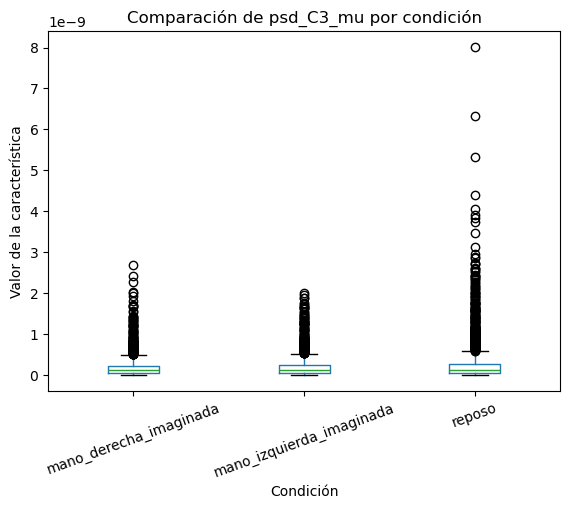

<Figure size 800x500 with 0 Axes>

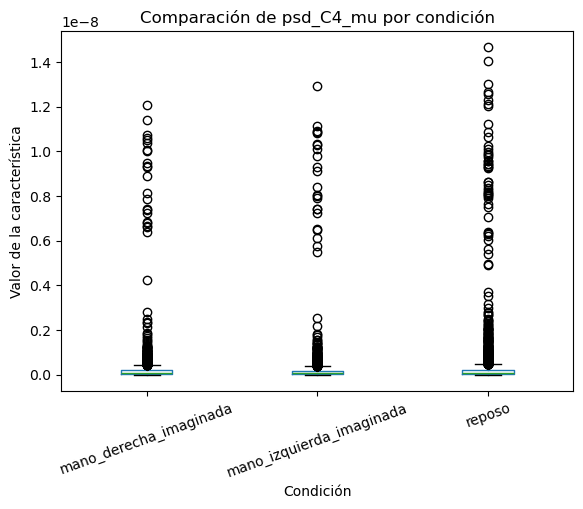

<Figure size 800x500 with 0 Axes>

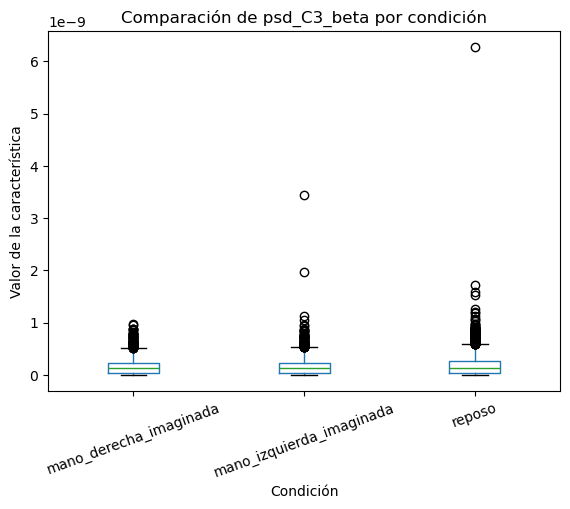

<Figure size 800x500 with 0 Axes>

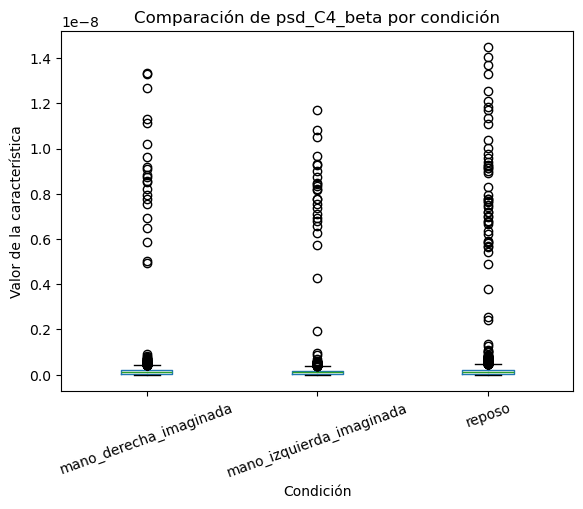

<Figure size 800x500 with 0 Axes>

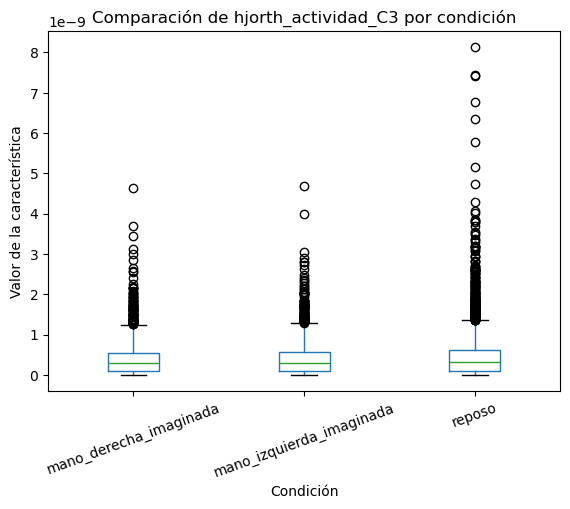

<Figure size 800x500 with 0 Axes>

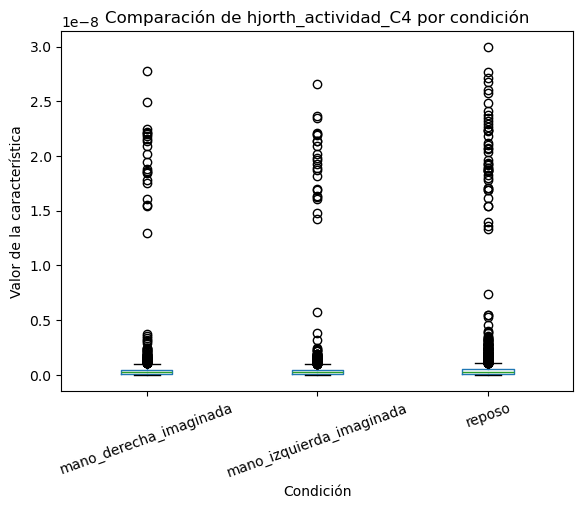

<Figure size 800x500 with 0 Axes>

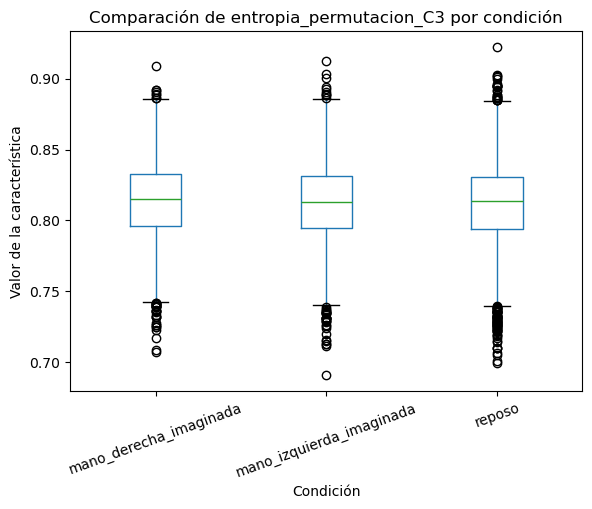

<Figure size 800x500 with 0 Axes>

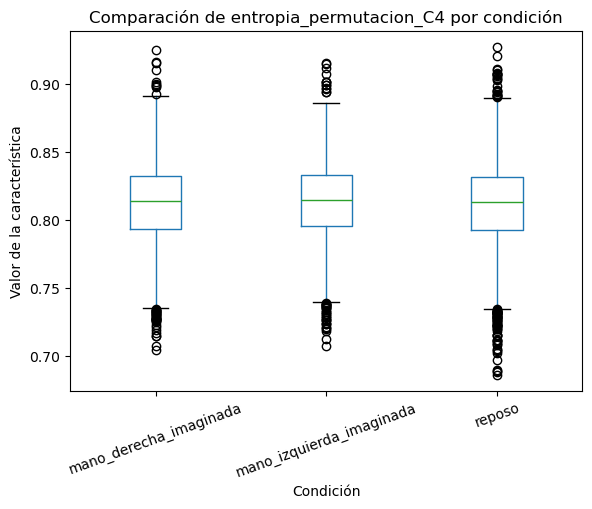

<Figure size 800x500 with 0 Axes>

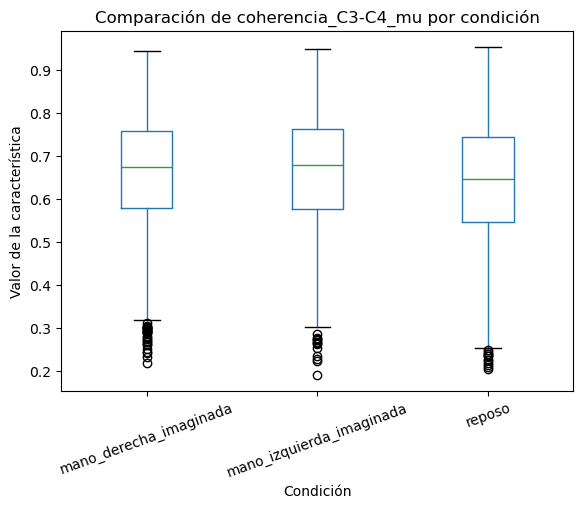

<Figure size 800x500 with 0 Axes>

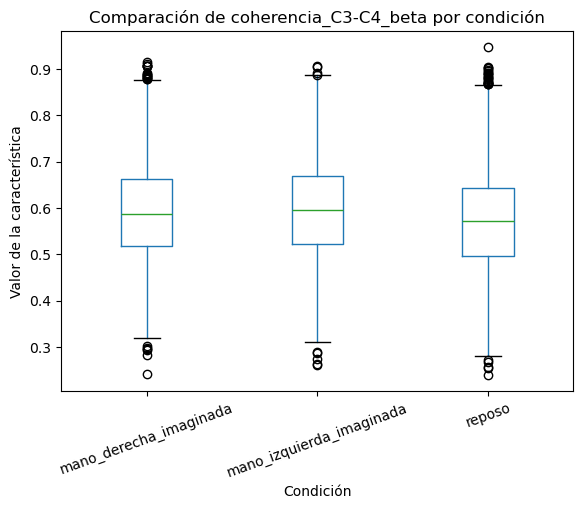

In [72]:
# ============================================================
# 45. BOXPLOTS POR CONDICIÓN
# ============================================================

for feature in features_a_graficar:

    plt.figure(figsize=(8, 5))

    df_features_wide_todos.boxplot(
        column=feature,
        by="condicion",
        grid=False
    )

    plt.title(f"Comparación de {feature} por condición")
    plt.suptitle("")
    plt.xlabel("Condición")
    plt.ylabel("Valor de la característica")
    plt.xticks(rotation=20)
    plt.show()

## Planteamiento de hipótesis

Para comparar las condiciones de reposo, imaginación de movimiento de mano izquierda e imaginación de movimiento de mano derecha, se plantean las siguientes hipótesis:

**Hipótesis nula (H0):**  
No existen diferencias estadísticamente significativas en el valor del índice EEG evaluado entre las condiciones de reposo, imaginación de mano izquierda e imaginación de mano derecha.

**Hipótesis alternativa (H1):**  
Existe al menos una diferencia estadísticamente significativa en el valor del índice EEG evaluado entre las condiciones de reposo, imaginación de mano izquierda e imaginación de mano derecha.

Como las señales EEG suelen presentar alta variabilidad entre sujetos y no se puede asumir inicialmente normalidad en la distribución de las características, se propone usar una prueba no paramétrica de Kruskal-Wallis para comparar las tres condiciones.

In [73]:
# ============================================================
# 47. PRUEBA KRUSKAL-WALLIS PARA TODAS LAS CARACTERÍSTICAS
# ============================================================

from scipy.stats import kruskal

resultados_pruebas = []

condiciones = df_features_wide_todos["condicion"].unique()

for feature in columnas_features:

    grupos = []

    for condicion in condiciones:
        valores = df_features_wide_todos.loc[
            df_features_wide_todos["condicion"] == condicion,
            feature
        ].dropna()

        grupos.append(valores)

    # Solo aplicar si cada grupo tiene datos suficientes
    if all(len(grupo) > 1 for grupo in grupos):

        estadistico, p_valor = kruskal(*grupos)

        resultados_pruebas.append({
            "feature": feature,
            "estadistico_kruskal": estadistico,
            "p_valor": p_valor
        })

df_pruebas = pd.DataFrame(resultados_pruebas)

df_pruebas = df_pruebas.sort_values(
    by="p_valor",
    ascending=True
).reset_index(drop=True)

df_pruebas.head(20)

,feature,estadistico_kruskal,p_valor
0,coherencia_Cz-C4_mu,98.199343,4.745518e-22
1,coherencia_C3-Cz_mu,92.752077,7.230067e-21
2,coherencia_C3-C4_beta,85.036886,3.423535e-19
3,coherencia_C3-C4_mu,75.096148,4.932631e-17
4,coherencia_Cz-C4_beta,69.264170,9.109122e-16
5,coherencia_C3-Cz_beta,68.165729,1.577611e-15
6,psd_C4_mu,31.734888,1.284862e-07
7,psd_C3_mu,28.687014,5.897855e-07
8,hjorth_complejidad_C3,20.968745,2.797016e-05
9,psd_C3_beta,19.626382,5.472494e-05


In [74]:
# ============================================================
# 48. IDENTIFICAR CARACTERÍSTICAS SIGNIFICATIVAS
# ============================================================

alpha = 0.05

df_pruebas["significativa"] = df_pruebas["p_valor"] < alpha

print("Cantidad de características significativas:")
print(df_pruebas["significativa"].sum())

display(df_pruebas.head(20))

Cantidad de características significativas:
18


,feature,estadistico_kruskal,p_valor,significativa
0,coherencia_Cz-C4_mu,98.199343,4.745518e-22,True
1,coherencia_C3-Cz_mu,92.752077,7.230067e-21,True
2,coherencia_C3-C4_beta,85.036886,3.423535e-19,True
3,coherencia_C3-C4_mu,75.096148,4.932631e-17,True
4,coherencia_Cz-C4_beta,69.264170,9.109122e-16,True
5,coherencia_C3-Cz_beta,68.165729,1.577611e-15,True
6,psd_C4_mu,31.734888,1.284862e-07,True
7,psd_C3_mu,28.687014,5.897855e-07,True
8,hjorth_complejidad_C3,20.968745,2.797016e-05,True
9,psd_C3_beta,19.626382,5.472494e-05,True


In [75]:
# ============================================================
# 49. SELECCIONAR FEATURES CON MAYOR DIFERENCIA ENTRE CONDICIONES
# ============================================================

top_features = df_pruebas.loc[
    df_pruebas["significativa"] == True,
    "feature"
].head(15).tolist()

print("Top características seleccionadas:")
for feature in top_features:
    print(feature)

Top características seleccionadas:
coherencia_Cz-C4_mu
coherencia_C3-Cz_mu
coherencia_C3-C4_beta
coherencia_C3-C4_mu
coherencia_Cz-C4_beta
coherencia_C3-Cz_beta
psd_C4_mu
psd_C3_mu
hjorth_complejidad_C3
psd_C3_beta
hjorth_complejidad_Cz
hjorth_actividad_C3
hjorth_actividad_C4
psd_C4_beta
psd_Cz_mu


<Figure size 800x500 with 0 Axes>

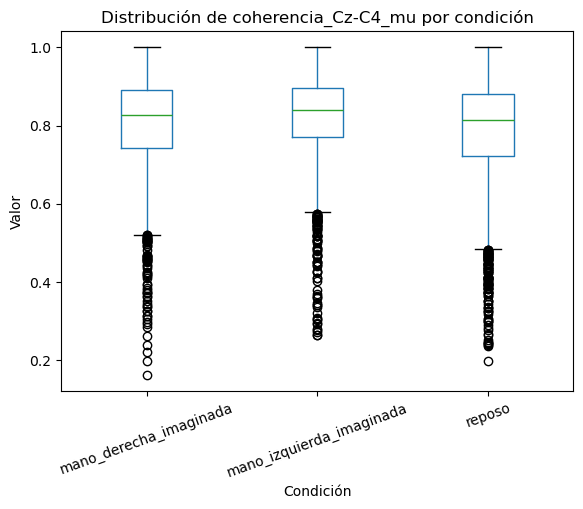

<Figure size 800x500 with 0 Axes>

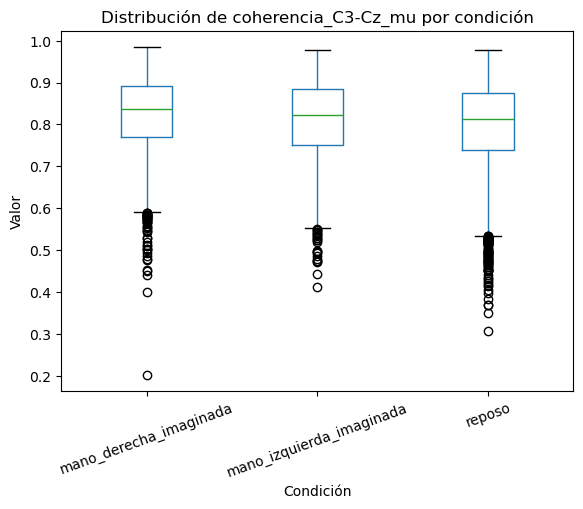

<Figure size 800x500 with 0 Axes>

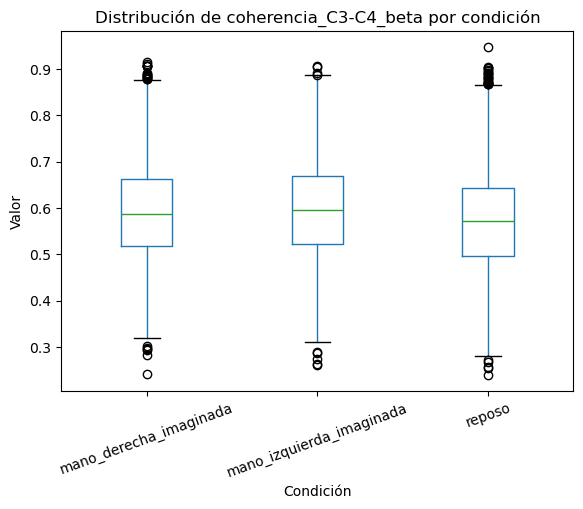

<Figure size 800x500 with 0 Axes>

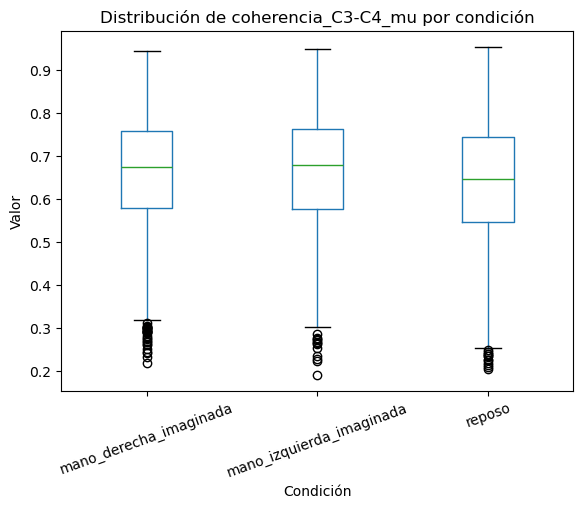

<Figure size 800x500 with 0 Axes>

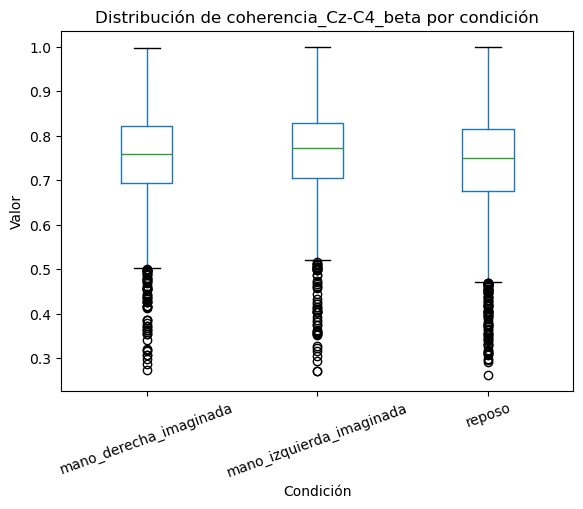

<Figure size 800x500 with 0 Axes>

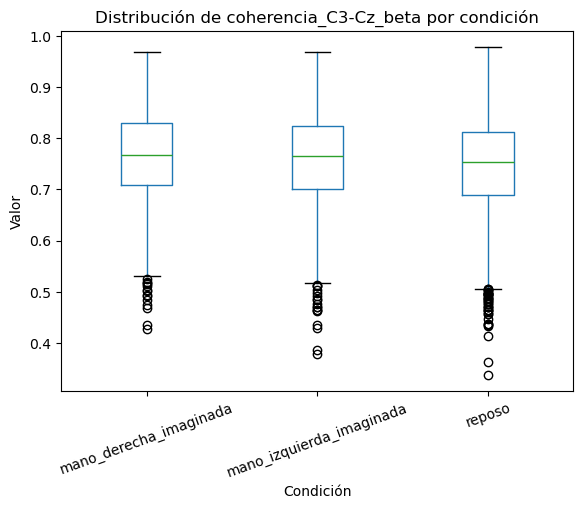

<Figure size 800x500 with 0 Axes>

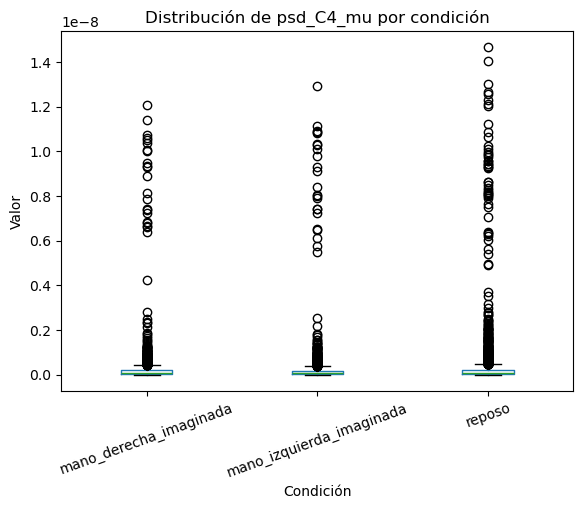

<Figure size 800x500 with 0 Axes>

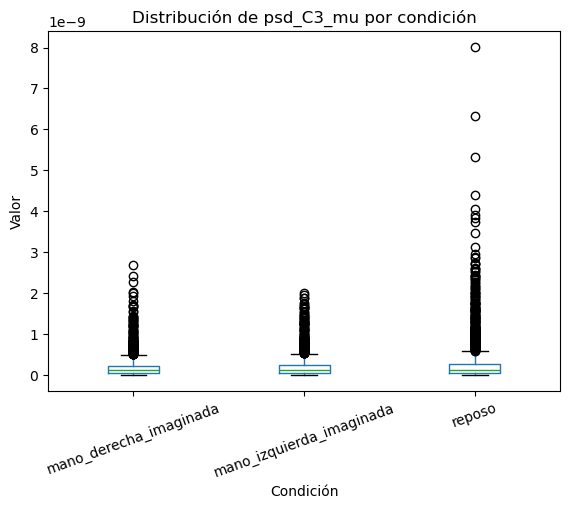

In [76]:
# ============================================================
# 50. GRAFICAR TOP FEATURES
# ============================================================

for feature in top_features[:8]:

    plt.figure(figsize=(8, 5))

    df_features_wide_todos.boxplot(
        column=feature,
        by="condicion",
        grid=False
    )

    plt.title(f"Distribución de {feature} por condición")
    plt.suptitle("")
    plt.xlabel("Condición")
    plt.ylabel("Valor")
    plt.xticks(rotation=20)
    plt.show()

In [77]:
# ============================================================
# 51. PREPARAR DATOS PARA CLASIFICACIÓN
# ============================================================

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
from sklearn.base import clone
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [78]:
# Usaremos las características con mayor diferencia estadística
features_clasificacion = top_features.copy()

print("Características seleccionadas para clasificación:")
for feature in features_clasificacion:
    print(feature)

Características seleccionadas para clasificación:
coherencia_Cz-C4_mu
coherencia_C3-Cz_mu
coherencia_C3-C4_beta
coherencia_C3-C4_mu
coherencia_Cz-C4_beta
coherencia_C3-Cz_beta
psd_C4_mu
psd_C3_mu
hjorth_complejidad_C3
psd_C3_beta
hjorth_complejidad_Cz
hjorth_actividad_C3
hjorth_actividad_C4
psd_C4_beta
psd_Cz_mu


In [79]:
# Crear dataframe de modelado eliminando filas con valores faltantes

df_modelo = df_features_wide_todos.dropna(
    subset=features_clasificacion + ["condicion"]
).copy()

X = df_modelo[features_clasificacion].values

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(df_modelo["condicion"])

nombres_clases = label_encoder.classes_

print("Forma de X:", X.shape)
print("Forma de y:", y.shape)
print("Clases:", nombres_clases)

print("\nCantidad de muestras por clase:")
print(df_modelo["condicion"].value_counts())

Forma de X: (9816, 15)
Forma de y: (9816,)
Clases: ['mano_derecha_imaginada' 'mano_izquierda_imaginada' 'reposo']

Cantidad de muestras por clase:
condicion
reposo                      4918
mano_izquierda_imaginada    2470
mano_derecha_imaginada      2428
Name: count, dtype: int64


In [80]:
# ============================================================
# 52. ESTRATEGIA DE VALIDACIÓN K-FOLD
# ============================================================

k = 5

cv = StratifiedKFold(
    n_splits=k,
    shuffle=True,
    random_state=42
)

print(f"Se usará validación cruzada estratificada con {k} folds.")

Se usará validación cruzada estratificada con 5 folds.


## Estrategia de entrenamiento basada en k-fold

Para evaluar los modelos de clasificación se utilizó validación cruzada estratificada con 5 particiones. Esta estrategia divide el conjunto de datos en cinco subconjuntos o folds. En cada iteración, cuatro folds se usan para entrenar el modelo y el fold restante se utiliza para validarlo.

Se eligió una estrategia estratificada porque las clases no tienen exactamente la misma cantidad de registros. De esta manera, cada fold conserva una proporción similar de muestras de reposo, imaginación de mano izquierda e imaginación de mano derecha.

Las variables de entrada del modelo corresponden a los índices EEG que mostraron mayor diferencia estadística entre condiciones, seleccionados a partir de la prueba de Kruskal-Wallis.

In [81]:
# ============================================================
# 53. FUNCIÓN GENERAL PARA EVALUAR MODELOS CON K-FOLD
# ============================================================

def evaluar_modelo_kfold(nombre_modelo, modelo, X, y, cv, nombres_clases, usar_escalado=True):
    """
    Evalúa un modelo usando validación cruzada k-fold estratificada.
    
    Retorna:
    - accuracy promedio
    - f1-score macro promedio
    - matriz de confusión acumulada
    - reporte de clasificación
    """

    accuracies = []
    f1_scores = []

    y_reales_total = []
    y_predichos_total = []

    for fold, (idx_train, idx_test) in enumerate(cv.split(X, y), start=1):

        X_train, X_test = X[idx_train], X[idx_test]
        y_train, y_test = y[idx_train], y[idx_test]

        if usar_escalado:
            clasificador = Pipeline([
                ("scaler", StandardScaler()),
                ("modelo", clone(modelo))
            ])
        else:
            clasificador = clone(modelo)

        clasificador.fit(X_train, y_train)

        y_pred = clasificador.predict(X_test)

        acc = accuracy_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred, average="macro")

        accuracies.append(acc)
        f1_scores.append(f1)

        y_reales_total.extend(y_test)
        y_predichos_total.extend(y_pred)

        print(f"{nombre_modelo} - Fold {fold}: Accuracy = {acc:.4f}, F1-macro = {f1:.4f}")

    matriz = confusion_matrix(
        y_reales_total,
        y_predichos_total
    )

    reporte = classification_report(
        y_reales_total,
        y_predichos_total,
        target_names=nombres_clases,
        output_dict=True
    )

    resultados = {
        "modelo": nombre_modelo,
        "accuracy_promedio": np.mean(accuracies),
        "accuracy_std": np.std(accuracies),
        "f1_macro_promedio": np.mean(f1_scores),
        "f1_macro_std": np.std(f1_scores),
        "matriz_confusion": matriz,
        "reporte": reporte
    }

    print("\nResumen:", nombre_modelo)
    print("Accuracy promedio:", np.mean(accuracies))
    print("F1 macro promedio:", np.mean(f1_scores))

    return resultados

In [82]:
# ============================================================
# 54. FUNCIÓN PARA GRAFICAR MATRIZ DE CONFUSIÓN
# ============================================================

def graficar_matriz_confusion(matriz, nombres_clases, titulo):
    """
    Grafica una matriz de confusión.
    """

    plt.figure(figsize=(6, 5))
    plt.imshow(matriz)
    plt.title(titulo)
    plt.xlabel("Clase predicha")
    plt.ylabel("Clase real")
    plt.xticks(np.arange(len(nombres_clases)), nombres_clases, rotation=30)
    plt.yticks(np.arange(len(nombres_clases)), nombres_clases)

    for i in range(matriz.shape[0]):
        for j in range(matriz.shape[1]):
            plt.text(j, i, matriz[i, j], ha="center", va="center")

    plt.colorbar()
    plt.tight_layout()
    plt.show()

SVM RBF - Fold 1: Accuracy = 0.4038, F1-macro = 0.3974
SVM RBF - Fold 2: Accuracy = 0.3872, F1-macro = 0.3847
SVM RBF - Fold 3: Accuracy = 0.3902, F1-macro = 0.3849
SVM RBF - Fold 4: Accuracy = 0.3897, F1-macro = 0.3853
SVM RBF - Fold 5: Accuracy = 0.3892, F1-macro = 0.3839

Resumen: SVM RBF
Accuracy promedio: 0.39201184230048153
F1 macro promedio: 0.3872378730240048


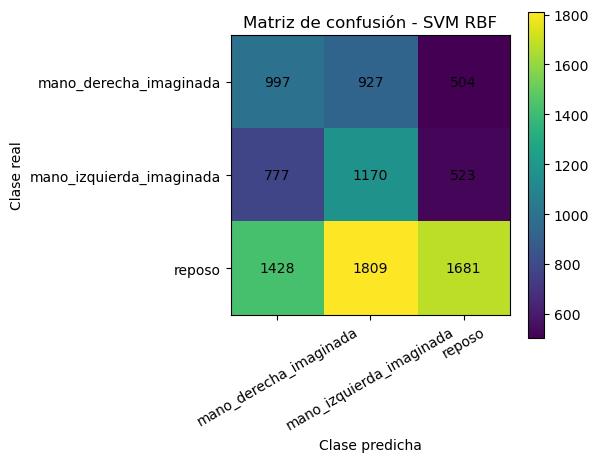

In [83]:
# ============================================================
# 55. MODELO SVM
# ============================================================

from sklearn.svm import SVC

modelo_svm = SVC(
    kernel="rbf",
    C=10,
    gamma="scale",
    class_weight="balanced",
    random_state=42
)

resultados_svm = evaluar_modelo_kfold(
    nombre_modelo="SVM RBF",
    modelo=modelo_svm,
    X=X,
    y=y,
    cv=cv,
    nombres_clases=nombres_clases,
    usar_escalado=True
)

graficar_matriz_confusion(
    resultados_svm["matriz_confusion"],
    nombres_clases,
    "Matriz de confusión - SVM RBF"
)

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.3/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.5/101.7 MB 1.1 MB/s eta 0:01:31
   ---------------------------------------- 0.8/101.7 MB 1.2 MB/s eta 0:01:28
   ---------------------------------------- 1.0/101.7 MB 1.2 MB/s eta 0:01:26
    --------------------------------------- 1.3/101.7 MB 1.2 MB/s eta 0:01:26
    --------------------------------------- 1.6/101.7 MB 1.1 MB/s eta 0:01:28
    --------------------------------------- 1.8/101.7 MB 1.1 MB/s eta 0:01:29
    --------------------------------------- 2.1/101.7 MB 1.1 MB/s eta 0:01:29
    --------------------------------------- 2.1/101.7 MB 1.1 MB/s eta 0:01:29
    --------------------------------------- 2.4/101.7 MB 1.1 MB/s eta 0:01:29
   - -------------------------------------- 2.6/101.7 MB 1.1 MB/s eta 0:01:30
   - --

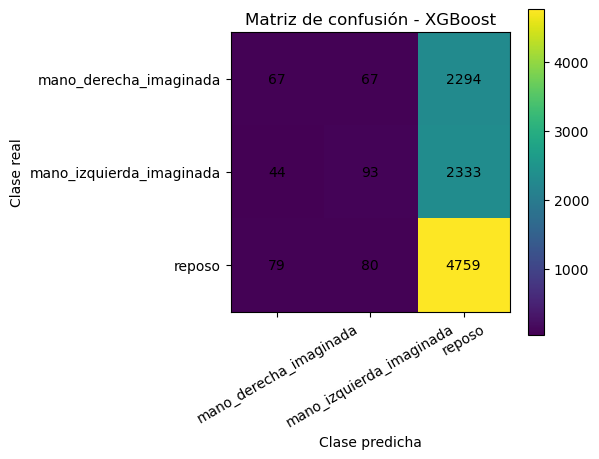

In [85]:
# ============================================================
# 56. MODELO XGBOOST
# ============================================================

# Si no tienes xgboost instalado, ejecuta:
!pip install xgboost

from xgboost import XGBClassifier

modelo_xgb = XGBClassifier(
    objective="multi:softprob",
    num_class=len(nombres_clases),
    eval_metric="mlogloss",
    n_estimators=200,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

resultados_xgb = evaluar_modelo_kfold(
    nombre_modelo="XGBoost",
    modelo=modelo_xgb,
    X=X,
    y=y,
    cv=cv,
    nombres_clases=nombres_clases,
    usar_escalado=False
)

graficar_matriz_confusion(
    resultados_xgb["matriz_confusion"],
    nombres_clases,
    "Matriz de confusión - XGBoost"
)

In [86]:
# ============================================================
# 57. TRES ARQUITECTURAS DE RED NEURONAL
# ============================================================

from sklearn.neural_network import MLPClassifier

modelo_mlp_1 = MLPClassifier(
    hidden_layer_sizes=(16,),
    activation="relu",
    solver="adam",
    max_iter=300,
    early_stopping=True,
    random_state=42
)

modelo_mlp_2 = MLPClassifier(
    hidden_layer_sizes=(32, 16),
    activation="relu",
    solver="adam",
    max_iter=300,
    early_stopping=True,
    random_state=42
)

modelo_mlp_3 = MLPClassifier(
    hidden_layer_sizes=(64, 32, 16),
    activation="relu",
    solver="adam",
    max_iter=300,
    early_stopping=True,
    random_state=42
)

MLP 1 capa 16 neuronas - Fold 1: Accuracy = 0.5031, F1-macro = 0.2538
MLP 1 capa 16 neuronas - Fold 2: Accuracy = 0.4972, F1-macro = 0.2504
MLP 1 capa 16 neuronas - Fold 3: Accuracy = 0.4997, F1-macro = 0.2516
MLP 1 capa 16 neuronas - Fold 4: Accuracy = 0.4957, F1-macro = 0.2643
MLP 1 capa 16 neuronas - Fold 5: Accuracy = 0.4957, F1-macro = 0.2502

Resumen: MLP 1 capa 16 neuronas
Accuracy promedio: 0.498267645951114
F1 macro promedio: 0.254043616765591


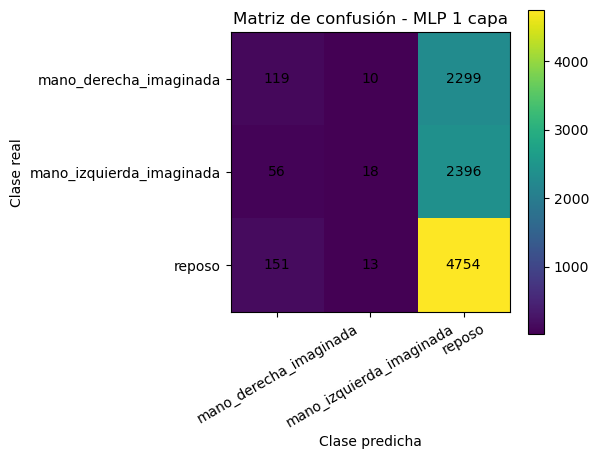

In [87]:
# Evaluar arquitectura 1

resultados_mlp_1 = evaluar_modelo_kfold(
    nombre_modelo="MLP 1 capa 16 neuronas",
    modelo=modelo_mlp_1,
    X=X,
    y=y,
    cv=cv,
    nombres_clases=nombres_clases,
    usar_escalado=True
)

graficar_matriz_confusion(
    resultados_mlp_1["matriz_confusion"],
    nombres_clases,
    "Matriz de confusión - MLP 1 capa"
)

MLP 2 capas 32-16 neuronas - Fold 1: Accuracy = 0.4903, F1-macro = 0.2874
MLP 2 capas 32-16 neuronas - Fold 2: Accuracy = 0.4997, F1-macro = 0.2286
MLP 2 capas 32-16 neuronas - Fold 3: Accuracy = 0.4997, F1-macro = 0.2223
MLP 2 capas 32-16 neuronas - Fold 4: Accuracy = 0.4992, F1-macro = 0.2284
MLP 2 capas 32-16 neuronas - Fold 5: Accuracy = 0.5028, F1-macro = 0.2382

Resumen: MLP 2 capas 32-16 neuronas
Accuracy promedio: 0.49837082772638
F1 macro promedio: 0.24099233640593334


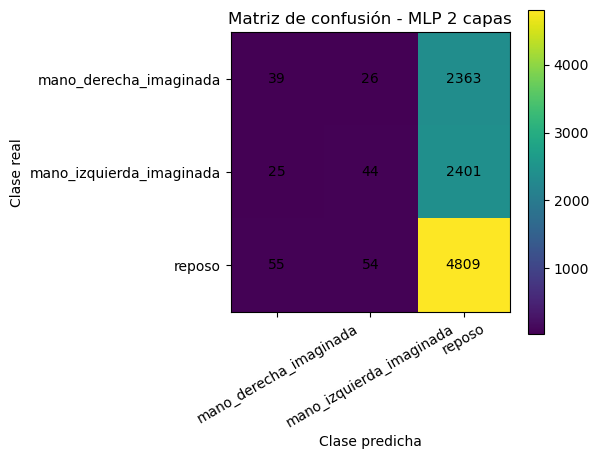

In [88]:
# Evaluar arquitectura 2

resultados_mlp_2 = evaluar_modelo_kfold(
    nombre_modelo="MLP 2 capas 32-16 neuronas",
    modelo=modelo_mlp_2,
    X=X,
    y=y,
    cv=cv,
    nombres_clases=nombres_clases,
    usar_escalado=True
)

graficar_matriz_confusion(
    resultados_mlp_2["matriz_confusion"],
    nombres_clases,
    "Matriz de confusión - MLP 2 capas"
)

MLP 3 capas 64-32-16 neuronas - Fold 1: Accuracy = 0.5010, F1-macro = 0.2315
MLP 3 capas 64-32-16 neuronas - Fold 2: Accuracy = 0.4941, F1-macro = 0.2632
MLP 3 capas 64-32-16 neuronas - Fold 3: Accuracy = 0.5013, F1-macro = 0.2226
MLP 3 capas 64-32-16 neuronas - Fold 4: Accuracy = 0.4997, F1-macro = 0.2221
MLP 3 capas 64-32-16 neuronas - Fold 5: Accuracy = 0.4972, F1-macro = 0.2305

Resumen: MLP 3 capas 64-32-16 neuronas
Accuracy promedio: 0.4986753929363282
F1 macro promedio: 0.23400127861700842


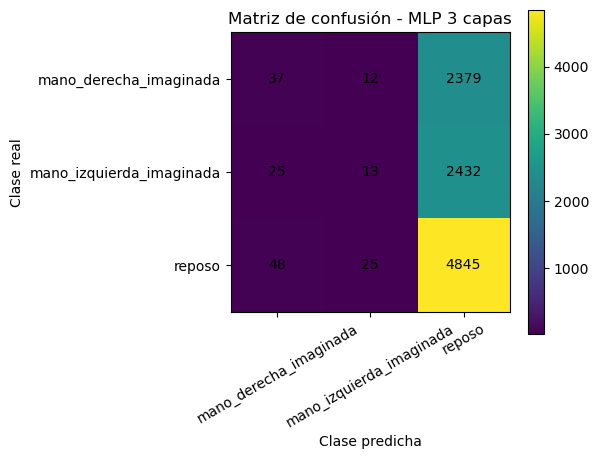

In [89]:
# Evaluar arquitectura 3

resultados_mlp_3 = evaluar_modelo_kfold(
    nombre_modelo="MLP 3 capas 64-32-16 neuronas",
    modelo=modelo_mlp_3,
    X=X,
    y=y,
    cv=cv,
    nombres_clases=nombres_clases,
    usar_escalado=True
)

graficar_matriz_confusion(
    resultados_mlp_3["matriz_confusion"],
    nombres_clases,
    "Matriz de confusión - MLP 3 capas"
)

In [90]:
# ============================================================
# 58. COMPARACIÓN GENERAL DE MODELOS
# ============================================================

resultados_modelos = [
    resultados_svm,
    resultados_xgb,
    resultados_mlp_1,
    resultados_mlp_2,
    resultados_mlp_3
]

df_resultados_modelos = pd.DataFrame([
    {
        "modelo": r["modelo"],
        "accuracy_promedio": r["accuracy_promedio"],
        "accuracy_std": r["accuracy_std"],
        "f1_macro_promedio": r["f1_macro_promedio"],
        "f1_macro_std": r["f1_macro_std"]
    }
    for r in resultados_modelos
])

df_resultados_modelos = df_resultados_modelos.sort_values(
    by="f1_macro_promedio",
    ascending=False
).reset_index(drop=True)

display(df_resultados_modelos)

,modelo,accuracy_promedio,accuracy_std,f1_macro_promedio,f1_macro_std
0,SVM RBF,0.392012,0.005969,0.387238,0.005099
1,XGBoost,0.501120,0.002693,0.261647,0.006212
2,MLP 1 capa 16 neuronas,0.498268,0.002819,0.254044,0.005291
3,MLP 2 capas 32-16 neuronas,0.498371,0.004216,0.240992,0.023768
4,MLP 3 capas 64-32-16 neuronas,0.498675,0.002688,0.234001,0.015126


## Discusión de la estrategia de clasificación

La clasificación se realizó usando las características EEG que presentaron mayor diferencia estadística entre las condiciones de reposo, imaginación de mano izquierda e imaginación de mano derecha. Estas características fueron seleccionadas a partir de la prueba de Kruskal-Wallis, usando como criterio principal el valor p.

Se utilizó una estrategia de validación cruzada estratificada con 5 folds. Esta metodología permite evaluar el desempeño de los modelos en diferentes particiones de los datos y reduce la dependencia de una única división entrenamiento-prueba. Además, al ser estratificada, mantiene proporciones similares de cada clase en los conjuntos de entrenamiento y validación.

Se evaluaron cinco modelos: una máquina de soporte vectorial con kernel RBF, un clasificador XGBoost y tres arquitecturas de red neuronal tipo perceptrón multicapa. Las tres redes neuronales se diferenciaron por el número de capas ocultas y neuronas: una red simple de una capa, una red intermedia de dos capas y una red más profunda de tres capas.

El desempeño de los modelos se comparó mediante accuracy, F1-score macro y matrices de confusión. El F1-score macro es especialmente útil en este caso porque las clases no tienen exactamente la misma cantidad de muestras.